# **Tuning, Validación e Interpretabilidad**

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from scipy.stats import randint, uniform

In [3]:
import sklearn
print(sklearn.__version__)

1.6.1


## Esto es con el ajuste que le aplicamos de la codificación

In [5]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================
from collections import Counter

df = pd.read_pickle('data_limpia.pkl')
target_col = 'credit_score'

y_raw = df[target_col].copy()
X = df.drop(columns=[target_col]).copy()

print(f"Shape df: {df.shape}")
print("Clases originales:")
print(y_raw.value_counts())

# =============================================================================
# ENCODING DEL TARGET — DOMAIN-ORDERED (Good→0, Standard→1, Poor→2)
# Consistente con Stacking + LAVA: codificación ANTES del split
# =============================================================================
class_order = ["Good", "Standard", "Poor"]
mapping = {cls: i for i, cls in enumerate(class_order)}
inverse_mapping = {i: cls for cls, i in mapping.items()}

y = y_raw.map(mapping)

print(f"\nMapping: {mapping}")
print(f"Distribución y: {Counter(y)}")

# =============================================================================
# SPLIT
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Valores únicos y_test: {np.unique(y_test)}")

# =============================================================================
# PREPROCESAMIENTO CON PIPELINE
# =============================================================================
numerical_cols = [
    'age', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card',
    'interest_rate', 'delay_from_due_date', 'num_of_delayed_payment',
    'changed_credit_limit', 'num_credit_inquiries', 'outstanding_debt',
    'credit_utilization_ratio', 'credit_history_age', 'total_emi_per_month',
    'amount_invested_monthly', 'monthly_balance'
]

categorical_cols = [
    'occupation', 'credit_mix', 'payment_of_min_amount', 'payment_behaviour'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

preprocessor.fit(X_train)

feature_names = (
    list(numerical_cols) +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)) +
    ['not_specified', 'credit_builder_loan', 'personal_loan', 'debt_consolidation_loan',
     'student_loan', 'payday_loan', 'mortgage_loan', 'auto_loan', 'home_equity_loan']
)

print(f"\nDimensionalidad final: {len(feature_names)} características")

Shape df: (100000, 29)
Clases originales:
credit_score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

Mapping: {'Good': 0, 'Standard': 1, 'Poor': 2}
Distribución y: Counter({1: 53174, 2: 28998, 0: 17828})

X_train: (70000, 28)
X_test : (30000, 28)
Valores únicos y_test: [0 1 2]

Dimensionalidad final: 48 características


# **KNN**

🧠 INICIANDO KNN AVANZADO OPTIMIZADO - ...

🎯 INICIANDO OPTIMIZACIÓN RÁPIDA CON RANDOMIZED SEARCH...
🔍 Ejecutando Randomized Search Optimizado...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
✅ Randomized Search completado en 2969.88s
🏆 Mejores parámetros: {'knn__algorithm': 'auto', 'knn__leaf_size': 20, 'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}
📈 Mejor score CV: 0.7446

🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...
🔍 Explorando combinaciones clave...
✅ Búsqueda manual rápida completada
🏆 Mejores parámetros manuales: {'n_neighbors': 9, 'weights': 'uniform', 'algorithm': 'ball_tree', 'p': 1, 'leaf_size': 25}
📈 Mejor score manual: 0.7191

🔍 COMPARANDO MODELOS OPTIMIZADOS...

🎯 Evaluando RandomSearch_KNN...
  ✅ F1-Score: 0.7694
  ✅ CV F1-Score: 0.7446 ± 0.0029

🎯 Evaluando ManualSearch_KNN...
  ✅ F1-Score: 0.7518
  ✅ CV F1-Score: 0.7191 ± 0.0015

🏆 MEJOR MODELO AVANZADO: RandomSearch_KNN
📊 F1-Score: 0.7694

🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...
✅ 

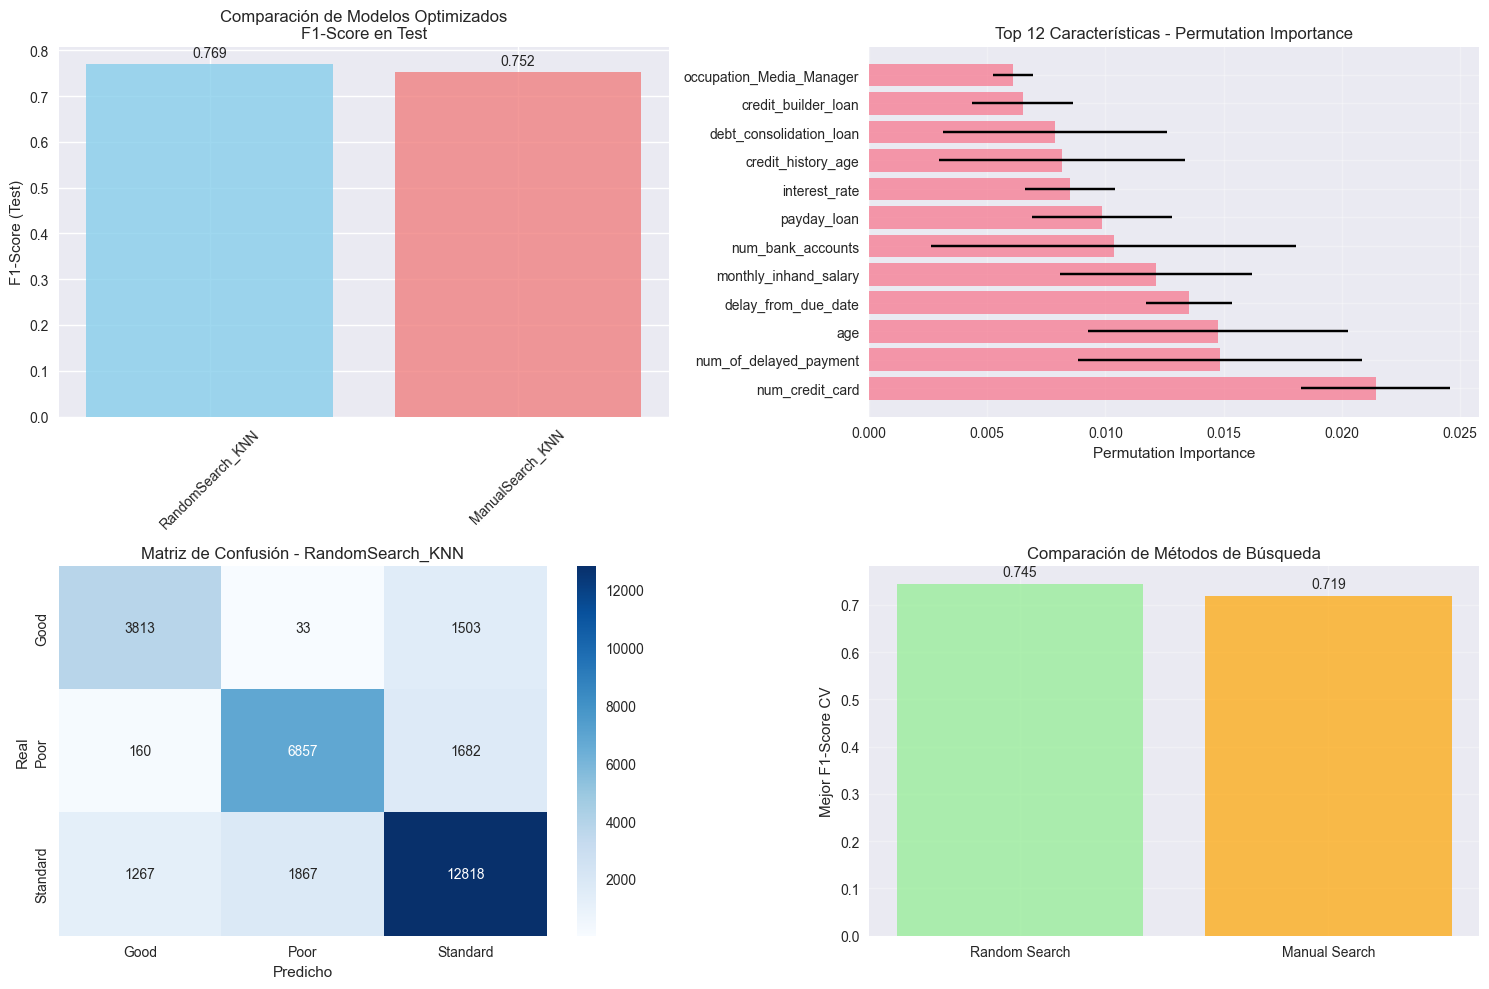


📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...
📊 Análisis de sobreajuste:
  • Diferencia promedio train-test: 0.1976
  • Configuraciones probadas: 25

🎯 RESUMEN FINAL - KNN AVANZADO OPTIMIZADO (VERSIÓN RÁPIDA)
⏱️  Tiempo total ejecución: 3372.42s
🏆 Mejor modelo: RandomSearch_KNN
📈 F1-Score Test: 0.7694 (76.94%)
🎯 Validación Cruzada: 0.7446 ± 0.0058

🔧 MEJORES HIPERPARÁMETROS:
  algorithm: auto
  leaf_size: 20
  n_neighbors: 9
  p: 1
  weights: distance

📊 CARACTERÍSTICAS MÁS IMPORTANTES:
  1. num_credit_card: 0.0214
  2. num_of_delayed_payment: 0.0148
  3. age: 0.0148
  4. delay_from_due_date: 0.0135
  5. monthly_inhand_salary: 0.0122

⚡ EFICIENCIA COMPUTACIONAL:
  Randomized Search: 2969.88s (25 iteraciones, 3-folds)
  Permutation Importance: 67.43s (5 repeticiones, 1000 muestras)

📋 REPORTE CLASIFICACIÓN (RandomSearch_KNN):
              precision    recall  f1-score   support

        Good       0.73      0.71      0.72      5349
        Poor       0.78      0.79      0.79      8699
   

In [7]:
# =============================================================================
# KNN AVANZADO OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================

print("🧠 INICIANDO KNN AVANZADO OPTIMIZADO - ...")
start_time = time.time()

# Configuraciones de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# =============================================================================
# CONFIGURACIÓN RÁPIDA - OPTIMIZACIÓN CON RANDOMIZED SEARCH (PRINCIPAL)
# =============================================================================

print(f"\n🎯 INICIANDO OPTIMIZACIÓN RÁPIDA CON RANDOMIZED SEARCH...")

# Definir pipeline
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_jobs=-1))
])

# Distribuciones optimizadas para Randomized Search (EVITAR 'brute')
param_dist = {
    'knn__n_neighbors': randint(3, 20),
    'knn__weights': ['uniform', 'distance'],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree'],  # ELIMINADO 'brute'
    'knn__p': [1, 2],
    'knn__leaf_size': randint(20, 40)
}

# Configurar Stratified K-Fold con MENOS folds para velocidad
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds en vez de 5

# Randomized Search CV optimizado
random_search = RandomizedSearchCV(
    knn_pipeline,
    param_dist,
    n_iter=25,  # REDUCIDO de 50 a 25
    cv=skf_fast,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

print("🔍 Ejecutando Randomized Search Optimizado...")
random_start = time.time()
random_search.fit(X_train, y_train_encoded)
random_time = time.time() - random_start

print(f"✅ Randomized Search completado en {random_time:.2f}s")
print(f"🏆 Mejores parámetros: {random_search.best_params_}")
print(f"📈 Mejor score CV: {random_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_knn_config_fast(n_neighbors, weights, algorithm, p, leaf_size):
    """Evalúa una configuración específica de KNN (versión rápida)"""
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            algorithm=algorithm,
            p=p,
            leaf_size=leaf_size,
            n_jobs=-1
        ))
    ])
    
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()

# Búsqueda manual optimizada - solo combinaciones prometedoras
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave...")
# Solo probar combinaciones más prometedoras basadas en conocimiento de dominio
promising_combinations = [
    (5, 'uniform', 'auto', 2, 30),
    (7, 'distance', 'auto', 2, 30),
    (9, 'uniform', 'ball_tree', 1, 25),
    (11, 'distance', 'kd_tree', 2, 35),
    (15, 'uniform', 'auto', 2, 30),
]

for k, weight, algo, p_val, leaf in promising_combinations:
    score = evaluate_knn_config_fast(k, weight, algo, p_val, leaf)
    manual_results.append({
        'n_neighbors': k, 
        'weights': weight, 
        'algorithm': algo,
        'p': p_val,
        'leaf_size': leaf,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {
            'n_neighbors': k, 
            'weights': weight, 
            'algorithm': algo,
            'p': p_val,
            'leaf_size': leaf
        }

print(f"✅ Búsqueda manual rápida completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual
knn_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(**best_manual_params, n_jobs=-1))
])
knn_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'RandomSearch_KNN': random_search.best_estimator_,
    'ManualSearch_KNN': knn_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada rápida
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (MUESTREO PARA VELOCIDAD)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1000 muestras)
sample_size = min(1000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['knn'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,  # REDUCIDO de 10 a 5
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 2, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance
plt.subplot(2, 2, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'], 
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Matriz de confusión del mejor modelo
plt.subplot(2, 2, 3)
y_pred_best_advanced = best_results_advanced['y_pred']
cm_best_advanced = confusion_matrix(y_test_encoded, y_pred_best_advanced)
sns.heatmap(cm_best_advanced, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 4: Comparación de métodos de búsqueda
plt.subplot(2, 2, 4)
search_methods = ['Random Search', 'Manual Search']
search_scores = [random_search.best_score_, best_manual_score]
search_times = [random_time, 0]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Randomized Search para análisis
results_df = pd.DataFrame(random_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - KNN AVANZADO OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'RandomSearch_KNN':
    best_params = random_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('knn__', '')
    print(f"  {param_name}: {value}")

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Randomized Search: {random_time:.2f}s (25 iteraciones, 3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1000 muestras)")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best_advanced, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'random_search_results': random_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# joblib.dump(advanced_results, 'knn_advanced_optimized.pkl')
# print(f"\n💾 Resultados optimizados guardados: 'knn_advanced_optimized.pkl'")

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_knn_model_optimized.pkl')
print(f"💾 Mejor modelo guardado: 'best_knn_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - KNN OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

# **Random Forest**

Imports de Random Forest cargados correctamente
Encoding verificado: {'Good': 0, 'Standard': 1, 'Poor': 2}
  Distribución train: {0: 12479, 1: 37222, 2: 20299}
  Distribución test:  {0: 5349, 1: 15952, 2: 8699}
  Valores únicos en y_train_encoded: [0 1 2]

INICIANDO RANDOM FOREST OPTIMIZADO...

INICIANDO OPTIMIZACIÓN CON RANDOMIZED SEARCH CV...
Ejecutando Randomized Search Optimizado...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Randomized Search completado en 516.42s
Mejores parámetros: {'rf__bootstrap': True, 'rf__class_weight': None, 'rf__max_depth': None, 'rf__max_features': 0.3, 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 4, 'rf__n_estimators': 130}
Mejor score CV: 0.7533

INICIANDO BÚSQUEDA MANUAL RÁPIDA...
Explorando combinaciones clave de Random Forest...
Búsqueda manual rápida completada
Mejores parámetros manuales: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'class_

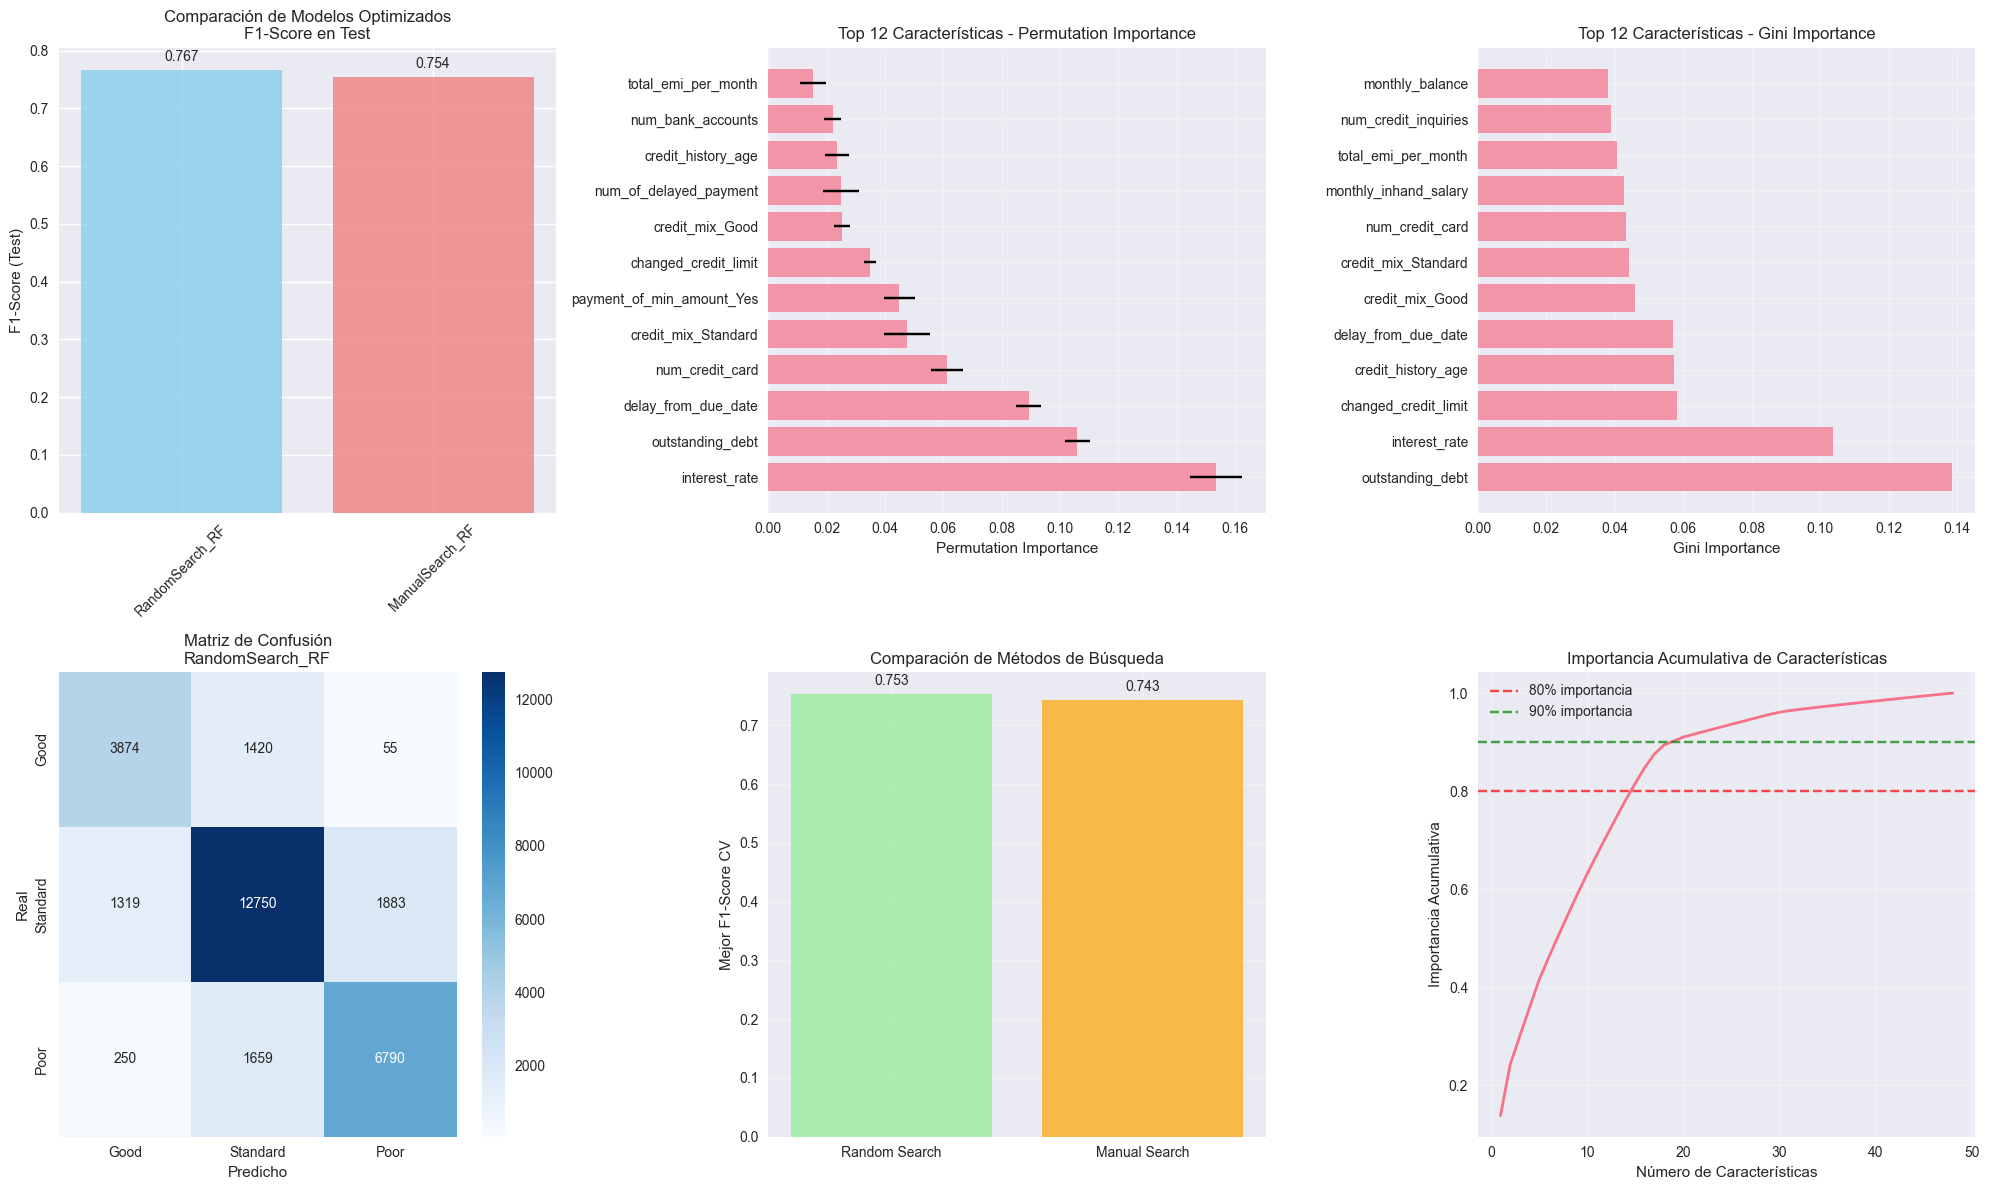


ANALIZANDO COMPORTAMIENTO DEL MODELO...
Análisis de sobreajuste:
  Diferencia promedio train-test: 0.0832
  Configuraciones probadas: 30
  Mejor configuración: 0.7533

RESUMEN FINAL - RANDOM FOREST AVANZADO OPTIMIZADO
Tiempo total ejecución: 701.57s
Mejor modelo: RandomSearch_RF
F1-Score Test: 0.7665 (76.65%)
Validación Cruzada: 0.7533 +/- 0.0057

MEJORES HIPERPARÁMETROS:
  bootstrap: True
  class_weight: None
  max_depth: None
  max_features: 0.3
  min_samples_leaf: 3
  min_samples_split: 4
  n_estimators: 130

CARACTERÍSTICAS MÁS IMPORTANTES:
  1. interest_rate: 0.1535
  2. outstanding_debt: 0.1059
  3. delay_from_due_date: 0.0893
  4. num_credit_card: 0.0612
  5. credit_mix_Standard: 0.0476

EFICIENCIA COMPUTACIONAL:
  Randomized Search: 516.42s (30 iteraciones, 5-folds)
  Permutation Importance: 45.12s (5 repeticiones, 2000 muestras)

ESTABILIDAD DEL MODELO:
  Característica más estable: credit_mix_Not Specified
  Número de características con >80% importancia: 14

REPORTE CLASIFI

In [8]:
# =============================================================================
# RANDOM FOREST — TUNING, VALIDACIÓN E INTERPRETABILIDAD
# Encoding: Domain-Ordered (Good→0, Standard→1, Poor→2)
# Consistente con Stacking + LAVA / XGBoost + LAVA
# =============================================================================

# =============================================================================
# IMPORTS
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from scipy.stats import randint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

print("Imports de Random Forest cargados correctamente")

# =============================================================================
# ENCODING DEL TARGET — DOMAIN-ORDERED (consistente con Stacking + LAVA)
# =============================================================================
# ANTES usábamos LabelEncoder (alfabético): Good→0, Poor→1, Standard→2
# =============================================================================
# ENCODING DEL TARGET — DOMAIN-ORDERED (Good→0, Standard→1, Poor→2)
# y_train / y_test ya vienen codificados desde la celda de carga de datos.
# No se re-aplica mapping aquí para evitar NaN por doble codificación.
# =============================================================================

y_train_encoded = y_train.values
y_test_encoded  = y_test.values

print(f"Encoding verificado: {mapping}")
print(f"  Distribución train: {pd.Series(y_train_encoded).value_counts().sort_index().to_dict()}")
print(f"  Distribución test:  {pd.Series(y_test_encoded).value_counts().sort_index().to_dict()}")
print(f"  Valores únicos en y_train_encoded: {np.unique(y_train_encoded)}")

# =============================================================================
# RANDOM FOREST OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================

print("\nINICIANDO RANDOM FOREST OPTIMIZADO...")
start_time = time.time()

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# OPTIMIZACIÓN CON RANDOMIZED SEARCH CV (PRINCIPAL)
# =============================================================================

print(f"\nINICIANDO OPTIMIZACIÓN CON RANDOMIZED SEARCH CV...")

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'rf__n_estimators': randint(50, 200),
    'rf__max_depth': [10, 15, 20, None],
    'rf__min_samples_split': randint(2, 15),
    'rf__min_samples_leaf': randint(1, 8),
    'rf__max_features': ['sqrt', 'log2', 0.3],
    'rf__bootstrap': [True],
    'rf__class_weight': [None, 'balanced']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_dist,
    n_iter=30,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

print("Ejecutando Randomized Search Optimizado...")
random_start = time.time()
random_search.fit(X_train, y_train_encoded)
random_time = time.time() - random_start

print(f"Randomized Search completado en {random_time:.2f}s")
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor score CV: {random_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\nINICIANDO BÚSQUEDA MANUAL RÁPIDA...")


def evaluate_rf_config_fast(n_estimators, max_depth, min_samples_split,
                            min_samples_leaf, max_features, class_weight):
    """Evalúa una configuración específica de Random Forest (versión rápida)"""
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('rf', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            bootstrap=True,
            class_weight=class_weight,
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv_scores = cross_val_score(
        model, X_train, y_train_encoded,
        cv=skf, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()


best_manual_score = 0
best_manual_params = {}
manual_results = []

print("Explorando combinaciones clave de Random Forest...")

promising_combinations = [
    (100, 15, 2, 1, 'sqrt', None),
    (150, 20, 5, 2, 'log2', None),
    (200, None, 10, 4, 'sqrt', 'balanced'),
    (100, 10, 2, 1, 0.3, None),
    (200, 15, 5, 2, 'log2', 'balanced'),
]

for n_est, max_d, min_split, min_leaf, max_feat, class_w in promising_combinations:
    score = evaluate_rf_config_fast(n_est, max_d, min_split, min_leaf, max_feat, class_w)
    manual_results.append({
        'n_estimators': n_est,
        'max_depth': max_d,
        'min_samples_split': min_split,
        'min_samples_leaf': min_leaf,
        'max_features': max_feat,
        'class_weight': class_w,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {
            'n_estimators': n_est,
            'max_depth': max_d,
            'min_samples_split': min_split,
            'min_samples_leaf': min_leaf,
            'max_features': max_feat,
            'bootstrap': True,
            'class_weight': class_w
        }

print(f"Búsqueda manual rápida completada")
print(f"Mejores parámetros manuales: {best_manual_params}")
print(f"Mejor score manual: {best_manual_score:.4f}")

rf_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(**best_manual_params, random_state=42, n_jobs=-1))
])
rf_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\nCOMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'RandomSearch_RF': random_search.best_estimator_,
    'ManualSearch_RF': rf_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\nEvaluando {model_name}...")

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')

    cv_scores = cross_val_score(
        model, X_train, y_train_encoded,
        cv=skf, scoring='f1_macro', n_jobs=-1
    )

    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.named_steps['rf'].feature_importances_
    }).sort_values('importance', ascending=False)

    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'feature_importance': feature_importance,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV F1-Score: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\nMEJOR MODELO AVANZADO: {best_model_name}")
print(f"F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (OPTIMIZADO)
# =============================================================================

print(f"\nCALCULANDO PERMUTATION IMPORTANCE...")

X_test_processed = preprocessor.transform(X_test)

sample_size = min(2000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['rf'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"Permutation Importance calculado en {perm_time:.2f}s")

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# ANÁLISIS DE ESTABILIDAD RÁPIDO
# =============================================================================

print(f"\nANALIZANDO ESTABILIDAD ENTRE MÉTODOS DE OPTIMIZACIÓN...")

all_methods_importance = []
for model_name in results_advanced.keys():
    importance_df = results_advanced[model_name]['feature_importance'].set_index('feature')['importance']
    all_methods_importance.append(importance_df)

stability_df = pd.DataFrame(all_methods_importance).T
stability_df.columns = list(results_advanced.keys())
stability_df['mean_importance'] = stability_df.mean(axis=1)
stability_df['std_importance'] = stability_df.std(axis=1)

print("Características más estables entre métodos de optimización:")
stable_features = stability_df.nsmallest(8, 'std_importance')['mean_importance']
print(stable_features.round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(20, 12))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 3, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance
plt.subplot(2, 3, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'],
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Importancia Gini del mejor modelo
plt.subplot(2, 3, 3)
top_gini = best_results_advanced['feature_importance'].head(12)
plt.barh(range(len(top_gini)), top_gini['importance'], alpha=0.7)
plt.yticks(range(len(top_gini)), top_gini['feature'])
plt.xlabel('Gini Importance')
plt.title('Top 12 Características - Gini Importance')
plt.grid(True, alpha=0.3)

# Gráfico 4: Matriz de confusión del mejor modelo
plt.subplot(2, 3, 4)
y_pred_best = best_results_advanced['y_pred']
cm_best = confusion_matrix(y_test_encoded, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order)
plt.title(f'Matriz de Confusión\n{best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 5: Comparación de métodos de búsqueda
plt.subplot(2, 3, 5)
search_methods = ['Random Search', 'Manual Search']
search_scores = [random_search.best_score_, best_manual_score]

bars = plt.bar(search_methods, search_scores, alpha=0.7,
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# Gráfico 6: Curva de importancia acumulativa
plt.subplot(2, 3, 6)
cumulative_importance = best_results_advanced['feature_importance']['importance'].cumsum()
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, linewidth=2)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% importancia')
plt.axhline(y=0.9, color='g', linestyle='--', alpha=0.7, label='90% importancia')
plt.xlabel('Número de Características')
plt.ylabel('Importancia Acumulativa')
plt.title('Importancia Acumulativa de Características')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

results_df = pd.DataFrame(random_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"Análisis de sobreajuste:")
print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  Configuraciones probadas: {len(results_df)}")
print(f"  Mejor configuración: {random_search.best_score_:.4f}")

# =============================================================================
# RESUMEN FINAL
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("RESUMEN FINAL - RANDOM FOREST AVANZADO OPTIMIZADO")
print("="*80)

print(f"Tiempo total ejecución: {execution_time:.2f}s")
print(f"Mejor modelo: {best_model_name}")
print(f"F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"Validación Cruzada: {best_results_advanced['cv_mean']:.4f} +/- {best_results_advanced['cv_std']*2:.4f}")

print(f"\nMEJORES HIPERPARÁMETROS:")
if best_model_name == 'RandomSearch_RF':
    best_params = random_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('rf__', '')
    print(f"  {param_name}: {value}")

print(f"\nCARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\nEFICIENCIA COMPUTACIONAL:")
print(f"  Randomized Search: {random_time:.2f}s (30 iteraciones, 5-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 2000 muestras)")

print(f"\nESTABILIDAD DEL MODELO:")
print(f"  Característica más estable: {stable_features.index[0]}")
print(f"  Número de características con >80% importancia: {(cumulative_importance <= 0.8).sum()}")

print(f"\nREPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best, target_names=class_order))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'random_search_results': random_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'stability_analysis': stability_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'class_order': class_order,
    'encoding_mapping': mapping,
}

# joblib.dump(advanced_results, 'random_forest_advanced_optimized.pkl')
# print(f"Resultados optimizados guardados: 'random_forest_advanced_optimized.pkl'")

joblib.dump(best_model_advanced, 'best_rf_model_optimized.pkl')
print(f"Mejor modelo guardado: 'best_rf_model_optimized.pkl'")

print("="*80)
print("ANÁLISIS COMPLETADO - RANDOM FOREST OPTIMIZADO (DOMAIN-ORDERED)")
print("="*80)

# **XGBoost**

In [7]:
# OPTIMIZACIÓN CON RANDOMIZED SEARCH CV (PRINCIPAL)
# =============================================================================
import xgboost as xgb
print(f"\n🎯 INICIANDO OPTIMIZACIÓN CON RANDOMIZED SEARCH CV...")

# Definir pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(
        random_state=42,
        n_jobs=-1,
        tree_method='hist',  # Más rápido que 'exact'
        eval_metric='mlogloss'
    ))
])

# Distribuciones optimizadas para Randomized Search
param_dist = {
    'xgb__n_estimators': randint(50, 200),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__subsample': uniform(0.6, 0.4),  # 0.6 a 1.0
    'xgb__colsample_bytree': uniform(0.6, 0.4),
    'xgb__reg_alpha': uniform(0, 1),
    'xgb__reg_lambda': uniform(1, 2),
    'xgb__min_child_weight': randint(1, 10)
}

# Configurar Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search CV optimizado
random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_dist,
    n_iter=25,  # REDUCIDO para mayor velocidad
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True
)

print("🔍 Ejecutando Randomized Search Optimizado...")
random_start = time.time()
random_search.fit(X_train, y_train_encoded)
random_time = time.time() - random_start

print(f"✅ Randomized Search completado en {random_time:.2f}s")
print(f"🏆 Mejores parámetros: {random_search.best_params_}")
print(f"📈 Mejor score CV: {random_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA SIMPLIFICADA (SIN EARLY STOPPING EN CV)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_xgb_config_simple(n_estimators, max_depth, learning_rate, subsample, 
                              colsample_bytree, reg_alpha, reg_lambda, min_child_weight):
    """Evalúa una configuración específica de XGBoost sin early stopping en CV"""
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('xgb', xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            min_child_weight=min_child_weight,
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            eval_metric='mlogloss'
        ))
    ])
    
    # Usar validación cruzada simple sin early stopping
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  # 3-folds para velocidad
        scoring='f1_macro', 
        n_jobs=-1
    )
    
    return cv_scores.mean()

# Búsqueda manual optimizada - combinaciones prometedoras para XGBoost
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave de XGBoost...")
# Combinaciones basadas en mejores prácticas para XGBoost
promising_combinations = [
    (100, 6, 0.1, 0.8, 0.8, 0.1, 1.0, 1),
    (150, 8, 0.05, 0.9, 0.7, 0.5, 1.5, 3),
    (200, 4, 0.2, 0.7, 0.9, 0.01, 2.0, 1),
    (100, 5, 0.15, 0.85, 0.75, 0.2, 1.2, 2),
    (120, 7, 0.08, 0.8, 0.8, 0.3, 1.8, 4),
]

for n_est, max_d, lr, subsample, colsample, alpha, lambda_, min_child in promising_combinations:
    try:
        score = evaluate_xgb_config_simple(n_est, max_d, lr, subsample, colsample, alpha, lambda_, min_child)
        manual_results.append({
            'n_estimators': n_est, 
            'max_depth': max_d, 
            'learning_rate': lr,
            'subsample': subsample,
            'colsample_bytree': colsample,
            'reg_alpha': alpha,
            'reg_lambda': lambda_,
            'min_child_weight': min_child,
            'score': score
        })
        if score > best_manual_score:
            best_manual_score = score
            best_manual_params = {
                'n_estimators': n_est,
                'max_depth': max_d, 
                'learning_rate': lr,
                'subsample': subsample,
                'colsample_bytree': colsample,
                'reg_alpha': alpha,
                'reg_lambda': lambda_,
                'min_child_weight': min_child
            }
        print(f"  ✅ Configuración: {n_est} árboles, {max_d} profundidad -> Score: {score:.4f}")
    except Exception as e:
        print(f"  ❌ Error en configuración: {e}")
        continue

print(f"✅ Búsqueda manual completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual final
xgb_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(**best_manual_params, random_state=42, n_jobs=-1, tree_method='hist'))
])
xgb_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'RandomSearch_XGB': random_search.best_estimator_,
    'ManualSearch_XGB': xgb_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada completa
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf, scoring='f1_macro', n_jobs=-1
    )
    
    # Importancia de características
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.named_steps['xgb'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'feature_importance': feature_importance,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (OPTIMIZADO)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (OPTIMIZADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1500 muestras)
sample_size = min(1500, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['xgb'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,  # REDUCIDO para velocidad
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# ANÁLISIS DE ESTABILIDAD RÁPIDO
# =============================================================================

print(f"\n📊 ANALIZANDO ESTABILIDAD ENTRE MÉTODOS DE OPTIMIZACIÓN...")

# Calcular importancia promedio entre métodos
all_methods_importance = []
for model_name in results_advanced.keys():
    importance_df = results_advanced[model_name]['feature_importance'].set_index('feature')['importance']
    all_methods_importance.append(importance_df)

stability_df = pd.DataFrame(all_methods_importance).T
stability_df.columns = list(results_advanced.keys())
stability_df['mean_importance'] = stability_df.mean(axis=1)
stability_df['std_importance'] = stability_df.std(axis=1)

print("Características más estables entre métodos de optimización:")
stable_features = stability_df.nsmallest(8, 'std_importance')['mean_importance']
print(stable_features.round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(20, 12))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 3, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance vs Gini Importance
plt.subplot(2, 3, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'], 
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Importancia Gini del mejor modelo
plt.subplot(2, 3, 3)
top_gini = best_results_advanced['feature_importance'].head(12)
plt.barh(range(len(top_gini)), top_gini['importance'], alpha=0.7)
plt.yticks(range(len(top_gini)), top_gini['feature'])
plt.xlabel('Gini Importance')
plt.title('Top 12 Características - Gini Importance')
plt.grid(True, alpha=0.3)

# Gráfico 4: Matriz de confusión del mejor modelo
plt.subplot(2, 3, 4)
y_pred_best = best_results_advanced['y_pred']
cm_best = confusion_matrix(y_test_encoded, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión\n{best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 5: Comparación de métodos de búsqueda
plt.subplot(2, 3, 5)
search_methods = ['Random Search', 'Manual Search']
search_scores = [random_search.best_score_, best_manual_score]
search_times = [random_time, 0]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# Gráfico 6: Curva de importancia acumulativa
plt.subplot(2, 3, 6)
cumulative_importance = best_results_advanced['feature_importance']['importance'].cumsum()
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, linewidth=2)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% importancia')
plt.axhline(y=0.9, color='g', linestyle='--', alpha=0.7, label='90% importancia')
plt.xlabel('Número de Características')
plt.ylabel('Importancia Acumulativa')
plt.title('Importancia Acumulativa de Características')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Randomized Search para análisis
results_df = pd.DataFrame(random_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")
print(f"  • Mejor configuración: {random_search.best_score_:.4f}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - XGBOOST AVANZADO OPTIMIZADO")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'RandomSearch_XGB':
    best_params = random_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('xgb__', '')
    print(f"  {param_name}: {value}")

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Randomized Search: {random_time:.2f}s (25 iteraciones, 5-folds)")
print(f"  Búsqueda Manual: 5 combinaciones (3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1500 muestras)")

print(f"\n🎯 ESTABILIDAD DEL MODELO:")
print(f"  Característica más estable: {stable_features.index[0]}")
print(f"  Número de características con >80% importancia: {(cumulative_importance <= 0.8).sum()}")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'random_search_results': random_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'stability_analysis': stability_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# joblib.dump(advanced_results, 'xgboost_advanced_optimized.pkl')
# print(f"\n💾 Resultados avanzados guardados: 'xgboost_advanced_optimized.pkl'")

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_xgboost_model_optimized.pkl')
print(f"💾 Mejor modelo guardado: 'best_xgboost_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - XGBOOST AVANZADO OPTIMIZADO")
print("="*80)


🎯 INICIANDO OPTIMIZACIÓN CON RANDOMIZED SEARCH CV...
🔍 Ejecutando Randomized Search Optimizado...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


ValueError: Input y contains NaN.

# Restantes

In [10]:
def print_model_summary(model_name, metrics, best_params, times, cv_scores):
    """
    Muestra un resumen completo del modelo en formato tabla con F1-Score prioritario

    Args:
        model_name: Nombre del modelo
        metrics: Dict con métricas (train_f1, test_f1, train_acc, test_acc, etc.)
        best_params: Dict con mejores hiperparámetros
        times: Dict con tiempos (grid_time, perm_time, total_time)
        cv_scores: Array con scores de cross-validation
    """

    # Calcular overfitting
    overfitting_gap = metrics['train_f1_macro'] - metrics['test_f1_macro']

    print("\n" + "="*100)
    print(f"{'RESUMEN FINAL - ' + model_name.upper():^100}")
    print("="*100)

    # 1. MÉTRICAS PRINCIPALES (F1-Score prioritario)
    print("\n📊 MÉTRICAS DE RENDIMIENTO (F1-Score Prioritario)")
    print("-" * 100)

    # Crear tabla de métricas
    metrics_data = {
        'Métrica': ['F1-Score', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall'],
        'Train': [
            f"{metrics['train_f1_macro']:.4f} ({metrics['train_f1_macro']*100:.2f}%)",
            f"{metrics['train_accuracy']:.4f} ({metrics['train_accuracy']*100:.2f}%)",
            f"{metrics['train_balanced_accuracy']:.4f} ({metrics['train_balanced_accuracy']*100:.2f}%)",
            f"{metrics.get('train_precision_macro', 0):.4f}" if 'train_precision_macro' in metrics else "N/A",
            f"{metrics.get('train_recall_macro', 0):.4f}" if 'train_recall_macro' in metrics else "N/A"
        ],
        'Test': [
            f"{metrics['test_f1_macro']:.4f} ({metrics['test_f1_macro']*100:.2f}%)",
            f"{metrics['test_accuracy']:.4f} ({metrics['test_accuracy']*100:.2f}%)",
            f"{metrics['test_balanced_accuracy']:.4f} ({metrics['test_balanced_accuracy']*100:.2f}%)",
            f"{metrics['test_precision_macro']:.4f} ({metrics['test_precision_macro']*100:.2f}%)",
            f"{metrics['test_recall_macro']:.4f} ({metrics['test_recall_macro']*100:.2f}%)"
        ],
        'Diferencia': [
            f"{overfitting_gap:+.4f}",
            f"{metrics['train_accuracy'] - metrics['test_accuracy']:+.4f}",
            f"{metrics['train_balanced_accuracy'] - metrics['test_balanced_accuracy']:+.4f}",
            "-",
            "-"
        ]
    }

    metrics_df = pd.DataFrame(metrics_data)
    print(metrics_df.to_string(index=False))

    # 2. VALIDACIÓN CRUZADA
    print(f"\n\n🎯 VALIDACIÓN CRUZADA (5-Folds)")
    print("-" * 100)
    cv_data = {
        'Métrica': ['F1-Score CV'],
        'Media': [f"{cv_scores.mean():.4f}"],
        'Desv. Est.': [f"{cv_scores.std():.4f}"],
        'Intervalo 95%': [f"{cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}"],
        'Min': [f"{cv_scores.min():.4f}"],
        'Max': [f"{cv_scores.max():.4f}"]
    }
    cv_df = pd.DataFrame(cv_data)
    print(cv_df.to_string(index=False))

    # 3. ANÁLISIS DE OVERFITTING
    print(f"\n\n⚠️  ANÁLISIS DE OVERFITTING")
    print("-" * 100)
    overfitting_status = "✓ Buen ajuste" if abs(overfitting_gap) < 0.05 else "⚠ Ligero sobreajuste" if abs(overfitting_gap) < 0.10 else "✗ Sobreajuste significativo"

    overfitting_data = {
        'Métrica': ['F1-Score Gap (Train - Test)', 'Estado'],
        'Valor': [f"{overfitting_gap:+.4f} ({abs(overfitting_gap)*100:.2f}%)", overfitting_status]
    }
    overfitting_df = pd.DataFrame(overfitting_data)
    print(overfitting_df.to_string(index=False))

    # 4. MEJORES HIPERPARÁMETROS
    print(f"\n\n⚙️  MEJORES HIPERPARÁMETROS")
    print("-" * 100)
    params_clean = {k.replace('classifier__', ''): v for k, v in best_params.items()}
    params_data = {
        'Parámetro': list(params_clean.keys()),
        'Valor': [str(v) for v in params_clean.values()]
    }
    params_df = pd.DataFrame(params_data)
    print(params_df.to_string(index=False))

    # 5. EFICIENCIA COMPUTACIONAL
    print(f"\n\n⏱️  EFICIENCIA COMPUTACIONAL")
    print("-" * 100)
    time_data = {
        'Etapa': ['Grid/Random Search', 'Permutation Importance', 'Validación Cruzada', 'Total'],
        'Tiempo (s)': [
            f"{times['grid_time']:.2f}",
            f"{times.get('perm_time', 0):.2f}",
            f"{times.get('cv_time', 0):.2f}",
            f"{times['total_time']:.2f}"
        ],
        'Tiempo (min)': [
            f"{times['grid_time']/60:.2f}",
            f"{times.get('perm_time', 0)/60:.2f}",
            f"{times.get('cv_time', 0)/60:.2f}",
            f"{times['total_time']/60:.2f}"
        ]
    }
    time_df = pd.DataFrame(time_data)
    print(time_df.to_string(index=False))

    # 6. RESUMEN EJECUTIVO
    print(f"\n\n📋 RESUMEN EJECUTIVO")
    print("-" * 100)
    print(f"🏆 Modelo: {model_name}")
    print(f"📈 F1-Score Test (Métrica Principal): {metrics['test_f1_macro']:.4f} ({metrics['test_f1_macro']*100:.2f}%)")
    print(f"✓  Validación Cruzada: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"⚠  Gap Train-Test: {overfitting_gap:+.4f} ({overfitting_status})")
    print(f"⏱  Tiempo Total: {times['total_time']/60:.2f} min")

    print("\n" + "="*100)
    print(f"{'✓ ANÁLISIS COMPLETADO - ' + model_name.upper():^100}")
    print("="*100 + "\n")


✅ Imports cargados correctamente
🧠 INICIANDO LOGISTIC REGRESSION OPTIMIZADO - ...

🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...
🔍 Ejecutando Grid Search Optimizado...
Fitting 3 folds for each of 38 candidates, totalling 114 fits
✅ Grid Search completado en 289.47s
🏆 Mejores parámetros: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
📈 Mejor score CV: 0.6430

🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...
🔍 Explorando combinaciones clave...
✅ Búsqueda manual rápida completada
🏆 Mejores parámetros manuales: {'C': 10.0, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced'}
📈 Mejor score manual: 0.6405

🔍 COMPARANDO MODELOS OPTIMIZADOS...

🎯 Evaluando GridSearch_LR...
  ✅ F1-Score: 0.6404
  ✅ CV F1-Score: 0.6430 ± 0.0029

🎯 Evaluando ManualSearch_LR...
  ✅ F1-Score: 0.6394
  ✅ CV F1-Score: 0.6405 ± 0.0036

🏆 MEJOR MODELO AVANZADO: GridSearch_LR
📊 F1-Score: 0.6404

🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...
✅

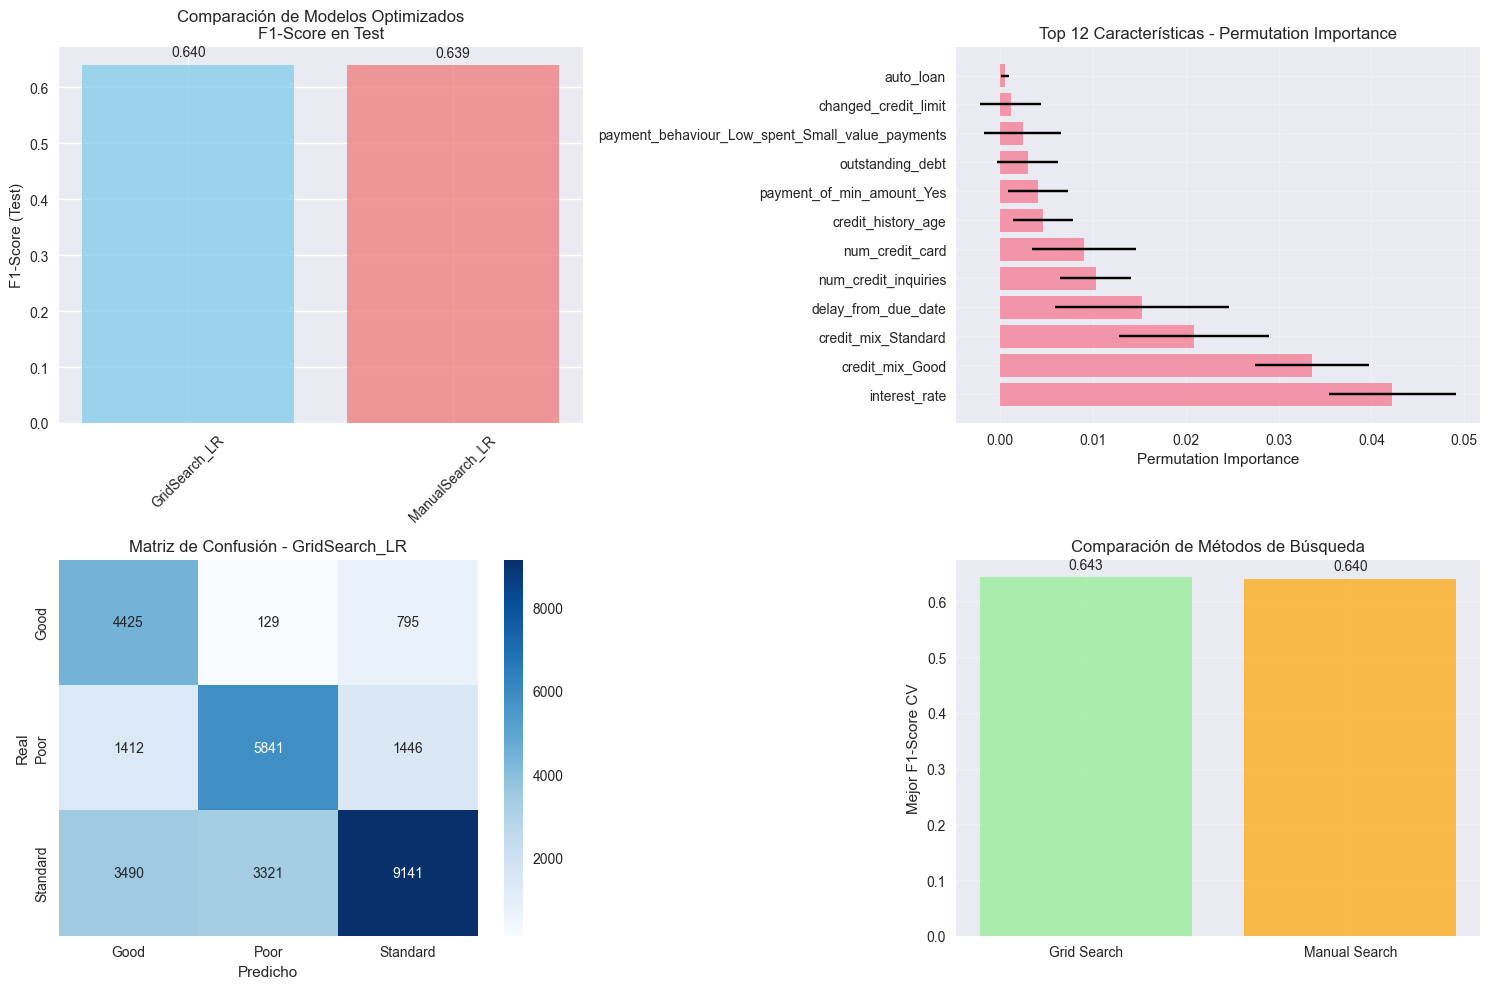


📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...
📊 Análisis de sobreajuste:
  • Diferencia promedio train-test: 0.0019
  • Configuraciones probadas: 38

🎯 RESUMEN FINAL - LOGISTIC REGRESSION OPTIMIZADO (VERSIÓN RÁPIDA)
⏱️  Tiempo total ejecución: 437.25s
🏆 Mejor modelo: GridSearch_LR
📈 F1-Score Test: 0.6404 (64.04%)
🎯 Validación Cruzada: 0.6430 ± 0.0059

🔧 MEJORES HIPERPARÁMETROS:
  C: 0.01
  class_weight: balanced
  penalty: l1
  solver: saga

📊 CARACTERÍSTICAS MÁS IMPORTANTES:
  1. interest_rate: 0.0423
  2. credit_mix_Good: 0.0336
  3. credit_mix_Standard: 0.0209
  4. delay_from_due_date: 0.0153
  5. num_credit_inquiries: 0.0103

⚡ EFICIENCIA COMPUTACIONAL:
  Grid Search: 289.47s (38 configuraciones, 3-folds)
  Permutation Importance: 0.15s (5 repeticiones, 1000 muestras)

📋 REPORTE CLASIFICACIÓN (GridSearch_LR):
              precision    recall  f1-score   support

        Good       0.47      0.83      0.60      5349
        Poor       0.63      0.67      0.65      8699
    Standard   

In [12]:
# =============================================================================
# LOGISTIC REGRESSION OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

print("✅ Imports cargados correctamente")
print("🧠 INICIANDO LOGISTIC REGRESSION OPTIMIZADO - ...")
start_time = time.time()

# Configuraciones de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# CONFIGURACIÓN RÁPIDA - OPTIMIZACIÓN CON GRID SEARCH (PRINCIPAL)
# =============================================================================

print(f"\n🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...")

# Definir pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        tol=1e-4,
        warm_start=False,
        n_jobs=-1
    ))
])

# Grid optimizado - separar por penalty
lr_param_grid = [
    # L1 penalty
    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['saga'],
        'classifier__class_weight': [None, 'balanced']
    },
    # L2 penalty
    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['saga'],
        'classifier__class_weight': [None, 'balanced']
    },
    # ElasticNet penalty
    {
        'classifier__penalty': ['elasticnet'],
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0.3, 0.5, 0.7],
        'classifier__class_weight': [None, 'balanced']
    }
]

# Configurar Stratified K-Fold
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid Search CV optimizado
grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=skf_fast,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("🔍 Ejecutando Grid Search Optimizado...")
grid_start = time.time()
grid_search.fit(X_train, y_train_encoded)
grid_time = time.time() - grid_start

print(f"✅ Grid Search completado en {grid_time:.2f}s")
print(f"🏆 Mejores parámetros: {grid_search.best_params_}")
print(f"📈 Mejor score CV: {grid_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_lr_config_fast(C, penalty, solver, class_weight, l1_ratio=None):
    """Evalúa una configuración específica de LR (versión rápida)"""
    params = {
        'C': C,
        'penalty': penalty,
        'solver': solver,
        'class_weight': class_weight,
        'max_iter': 1000,
        'random_state': 42,
        'n_jobs': -1
    }
    if l1_ratio is not None:
        params['l1_ratio'] = l1_ratio
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(**params))
    ])
    
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()

# Búsqueda manual optimizada - solo combinaciones prometedoras
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave...")
promising_combinations = [
    (1.0, 'l2', 'saga', None, None),
    (10.0, 'l2', 'saga', 'balanced', None),
    (1.0, 'l1', 'saga', None, None),
    (10.0, 'l1', 'saga', 'balanced', None),
    (1.0, 'elasticnet', 'saga', None, 0.5),
]

for C, penalty, solver, class_weight, l1_ratio in promising_combinations:
    score = evaluate_lr_config_fast(C, penalty, solver, class_weight, l1_ratio)
    manual_results.append({
        'C': C,
        'penalty': penalty,
        'solver': solver,
        'class_weight': class_weight,
        'l1_ratio': l1_ratio,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {
            'C': C,
            'penalty': penalty,
            'solver': solver,
            'class_weight': class_weight
        }
        if l1_ratio is not None:
            best_manual_params['l1_ratio'] = l1_ratio

print(f"✅ Búsqueda manual rápida completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual
lr_manual_params = best_manual_params.copy()
lr_manual_params.update({
    'max_iter': 1000,
    'random_state': 42,
    'n_jobs': -1
})
lr_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**lr_manual_params))
])
lr_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'GridSearch_LR': grid_search.best_estimator_,
    'ManualSearch_LR': lr_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada rápida
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (MUESTREO PARA VELOCIDAD)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1000 muestras)
sample_size = min(1000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['classifier'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 2, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance
plt.subplot(2, 2, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'], 
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Matriz de confusión del mejor modelo
plt.subplot(2, 2, 3)
y_pred_best_advanced = best_results_advanced['y_pred']
cm_best_advanced = confusion_matrix(y_test_encoded, y_pred_best_advanced)
sns.heatmap(cm_best_advanced, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 4: Comparación de métodos de búsqueda
plt.subplot(2, 2, 4)
search_methods = ['Grid Search', 'Manual Search']
search_scores = [grid_search.best_score_, best_manual_score]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Grid Search para análisis
results_df = pd.DataFrame(grid_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - LOGISTIC REGRESSION OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'GridSearch_LR':
    best_params = grid_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"  {param_name}: {value}")

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Grid Search: {grid_time:.2f}s (38 configuraciones, 3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1000 muestras)")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best_advanced, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'grid_search_results': grid_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_lr_model_optimized.pkl')
print(f"\n💾 Mejor modelo guardado: 'best_lr_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - LOGISTIC REGRESSION OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

✅ Imports cargados correctamente
🧠 INICIANDO RIDGE CLASSIFIER OPTIMIZADO - ...

🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...
🔍 Ejecutando Grid Search Optimizado...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
✅ Grid Search completado en 59.68s
🏆 Mejores parámetros: {'classifier__alpha': 1000, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lsqr'}
📈 Mejor score CV: 0.6345

🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...
🔍 Explorando combinaciones clave...
✅ Búsqueda manual rápida completada
🏆 Mejores parámetros manuales: {'alpha': 10.0, 'solver': 'auto', 'class_weight': 'balanced'}
📈 Mejor score manual: 0.6342

🔍 COMPARANDO MODELOS OPTIMIZADOS...

🎯 Evaluando GridSearch_Ridge...
  ✅ F1-Score: 0.6337
  ✅ CV F1-Score: 0.6345 ± 0.0026

🎯 Evaluando ManualSearch_Ridge...
  ✅ F1-Score: 0.6333
  ✅ CV F1-Score: 0.6342 ± 0.0026

🏆 MEJOR MODELO AVANZADO: GridSearch_Ridge
📊 F1-Score: 0.6337

🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...
✅ Permutation Importance calculado

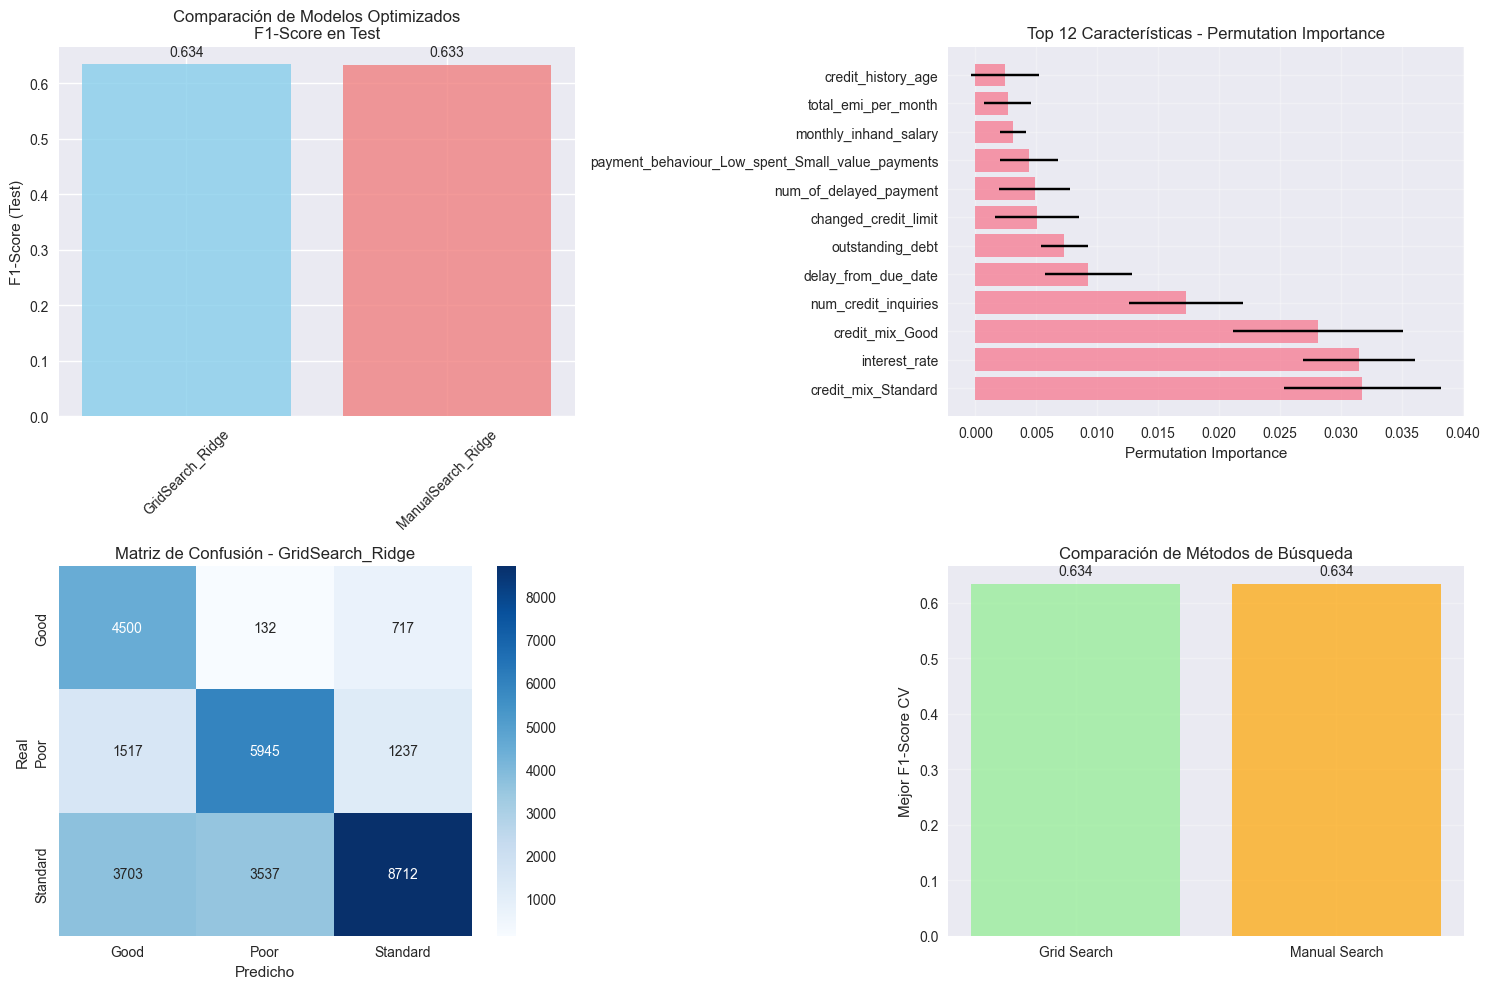


📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...
📊 Análisis de sobreajuste:
  • Diferencia promedio train-test: 0.0008
  • Configuraciones probadas: 72

🎯 RESUMEN FINAL - RIDGE CLASSIFIER OPTIMIZADO (VERSIÓN RÁPIDA)
⏱️  Tiempo total ejecución: 89.38s
🏆 Mejor modelo: GridSearch_Ridge
📈 F1-Score Test: 0.6337 (63.37%)
🎯 Validación Cruzada: 0.6345 ± 0.0053

🔧 MEJORES HIPERPARÁMETROS:
  alpha: 1000
  class_weight: balanced
  solver: lsqr

📊 CARACTERÍSTICAS MÁS IMPORTANTES:
  1. credit_mix_Standard: 0.0318
  2. interest_rate: 0.0315
  3. credit_mix_Good: 0.0281
  4. num_credit_inquiries: 0.0173
  5. delay_from_due_date: 0.0093

⚡ EFICIENCIA COMPUTACIONAL:
  Grid Search: 59.68s (72 configuraciones, 3-folds)
  Permutation Importance: 0.18s (5 repeticiones, 1000 muestras)

📋 REPORTE CLASIFICACIÓN (GridSearch_Ridge):
              precision    recall  f1-score   support

        Good       0.46      0.84      0.60      5349
        Poor       0.62      0.68      0.65      8699
    Standard       0.82 

In [14]:
# =============================================================================
# RIDGE CLASSIFIER OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================

from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
print("✅ Imports cargados correctamente")


print("🧠 INICIANDO RIDGE CLASSIFIER OPTIMIZADO - ...")
start_time = time.time()

# Configuraciones de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# CONFIGURACIÓN RÁPIDA - OPTIMIZACIÓN CON GRID SEARCH (PRINCIPAL)
# =============================================================================

print(f"\n🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...")

# Definir pipeline
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RidgeClassifier(
        random_state=42,
        tol=1e-4
    ))
])

# Grid de hiperparámetros optimizado
ridge_param_grid = {
    'classifier__alpha': [0.01, 0.1, 1, 10, 100, 1000],
    'classifier__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],
    'classifier__class_weight': [None, 'balanced']
}

# Configurar Stratified K-Fold
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid Search CV optimizado
grid_search = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=skf_fast,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("🔍 Ejecutando Grid Search Optimizado...")
grid_start = time.time()
grid_search.fit(X_train, y_train_encoded)
grid_time = time.time() - grid_start

print(f"✅ Grid Search completado en {grid_time:.2f}s")
print(f"🏆 Mejores parámetros: {grid_search.best_params_}")
print(f"📈 Mejor score CV: {grid_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_ridge_config_fast(alpha, solver, class_weight):
    """Evalúa una configuración específica de Ridge (versión rápida)"""
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RidgeClassifier(
            alpha=alpha,
            solver=solver,
            class_weight=class_weight,
            random_state=42,
            tol=1e-4
        ))
    ])
    
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()

# Búsqueda manual optimizada - solo combinaciones prometedoras
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave...")
promising_combinations = [
    (1.0, 'auto', None),
    (10.0, 'auto', 'balanced'),
    (100.0, 'saga', None),
    (1.0, 'sag', 'balanced'),
    (10.0, 'lsqr', None),
]

for alpha, solver, class_weight in promising_combinations:
    score = evaluate_ridge_config_fast(alpha, solver, class_weight)
    manual_results.append({
        'alpha': alpha,
        'solver': solver,
        'class_weight': class_weight,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {
            'alpha': alpha,
            'solver': solver,
            'class_weight': class_weight
        }

print(f"✅ Búsqueda manual rápida completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual
ridge_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RidgeClassifier(**best_manual_params, random_state=42, tol=1e-4))
])
ridge_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'GridSearch_Ridge': grid_search.best_estimator_,
    'ManualSearch_Ridge': ridge_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada rápida
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (MUESTREO PARA VELOCIDAD)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1000 muestras)
sample_size = min(1000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['classifier'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 2, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance
plt.subplot(2, 2, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'], 
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Matriz de confusión del mejor modelo
plt.subplot(2, 2, 3)
y_pred_best_advanced = best_results_advanced['y_pred']
cm_best_advanced = confusion_matrix(y_test_encoded, y_pred_best_advanced)
sns.heatmap(cm_best_advanced, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 4: Comparación de métodos de búsqueda
plt.subplot(2, 2, 4)
search_methods = ['Grid Search', 'Manual Search']
search_scores = [grid_search.best_score_, best_manual_score]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Grid Search para análisis
results_df = pd.DataFrame(grid_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - RIDGE CLASSIFIER OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'GridSearch_Ridge':
    best_params = grid_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"  {param_name}: {value}")

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Grid Search: {grid_time:.2f}s (72 configuraciones, 3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1000 muestras)")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best_advanced, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'grid_search_results': grid_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_ridge_model_optimized.pkl')
print(f"\n💾 Mejor modelo guardado: 'best_ridge_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - RIDGE CLASSIFIER OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

In [ ]:
# ============================================================================
# LOGISTIC REGRESSION - TUNING
# ============================================================================

print("\n" + "="*80)
print("MODELO 1/5: LOGISTIC REGRESSION")
print("="*80)

try:
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.inspection import permutation_importance
    from scipy.stats import loguniform
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score,
                                 classification_report, confusion_matrix)

    start_time = time.time()

    # Pipeline
    lr_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            tol=1e-4,
            warm_start=False
        ))
    ])

    # Grid optimizado - separar por penalty
    lr_param_grid = [
        # L1 penalty
        {
            'classifier__penalty': ['l1'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['saga'],
            'classifier__class_weight': [None, 'balanced']
        },
        # L2 penalty
        {
            'classifier__penalty': ['l2'],
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['saga'],
            'classifier__class_weight': [None, 'balanced']
        },
        # ElasticNet penalty
        {
            'classifier__penalty': ['elasticnet'],
            'classifier__C': [0.1, 1, 10],
            'classifier__solver': ['saga'],
            'classifier__l1_ratio': [0.3, 0.5, 0.7],
            'classifier__class_weight': [None, 'balanced']
        }
    ]

    print("\nHiperparametros a optimizar:")
    print("   L1: C=[0.01-100], class_weight=[None, balanced]")
    print("   L2: C=[0.01-100], class_weight=[None, balanced]")
    print("   ElasticNet: C=[0.1-10], l1_ratio=[0.3-0.7], class_weight=[None, balanced]")
    print(f"\nCombinaciones totales: 38 (optimizado)\n")

    # GridSearch
    lr_grid = GridSearchCV(
        lr_pipeline,
        lr_param_grid,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        pre_dispatch='2*n_jobs',
        error_score='raise',
        return_train_score=True
    )

    print("Iniciando busqueda de hiperparametros...\n")
    grid_start = time.time()
    lr_grid.fit(X_train, y_train)
    grid_time = time.time() - grid_start

    print(f"\nEntrenamiento completado en {grid_time:.2f}s ({grid_time/60:.2f} min)")
    print(f"Mejor CV score (F1-Macro): {lr_grid.best_score_:.4f}")
    print(f"Mejores parametros: {lr_grid.best_params_}")

    # =========================================================================
    # ANÁLISIS DE COMPORTAMIENTO
    # =========================================================================

    print(f"\nANALIZANDO COMPORTAMIENTO DEL MODELO...")

    results_df = pd.DataFrame(lr_grid.cv_results_)
    train_scores = results_df['mean_train_score']
    test_scores = results_df['mean_test_score']
    gap = train_scores - test_scores

    print(f"\nAnalisis de sobreajuste:")
    print(f"  Diferencia promedio train-test: {gap.mean():.4f}")
    print(f"  Configuraciones probadas: {len(results_df)}")

    # =========================================================================
    # OBTENER FEATURE NAMES DEL PIPELINE ENTRENADO
    # =========================================================================

    print(f"\nOBTENIENDO NOMBRES DE FEATURES...")

    fitted_preprocessor = lr_grid.best_estimator_.named_steps['preprocessor']
    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)
    n_features_actual = X_train_transformed.shape[1]

    print(f"Dimensiones despues del preprocesamiento: {X_train_transformed.shape}")
    print(f"Numero real de features: {n_features_actual}")

    try:
        feature_names = fitted_preprocessor.get_feature_names_out()
        print(f"Feature names obtenidos automaticamente: {len(feature_names)}")
    except:
        feature_names = []
        for name, transformer, columns in fitted_preprocessor.transformers_:
            if name == 'num':
                feature_names.extend([f'num__{col}' for col in columns])
            elif name == 'cat':
                if hasattr(transformer.named_steps['onehot'], 'get_feature_names_out'):
                    cat_features = transformer.named_steps['onehot'].get_feature_names_out(columns)
                    feature_names.extend([f'cat__{feat}' for feat in cat_features])
        print(f"Feature names generados manualmente: {len(feature_names)}")

    if len(feature_names) != n_features_actual:
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {n_features_actual}")
        if len(feature_names) < n_features_actual:
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), n_features_actual)]
        else:
            feature_names = list(feature_names)[:n_features_actual]

    print(f"Total de features despues del ajuste: {len(feature_names)}")

    # =========================================================================
    # PERMUTATION IMPORTANCE
    # =========================================================================

    print(f"\nCALCULANDO IMPORTANCIA DE FEATURES...")
    perm_start = time.time()

    perm_result = permutation_importance(
        lr_grid.best_estimator_,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring='f1_macro'
    )

    perm_time = time.time() - perm_start

    print(f"Dimensiones de importancias: {len(perm_result.importances_mean)}")
    print(f"Dimensiones de feature_names: {len(feature_names)}")

    if len(feature_names) != len(perm_result.importances_mean):
        print(f"ADVERTENCIA: Ajustando feature_names de {len(feature_names)} a {len(perm_result.importances_mean)}")
        if len(feature_names) < len(perm_result.importances_mean):
            feature_names = list(feature_names) + [f'feature_{i}' for i in range(len(feature_names), len(perm_result.importances_mean))]
        else:
            feature_names = list(feature_names)[:len(perm_result.importances_mean)]

    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std
    }).sort_values('importance_mean', ascending=False)

    print(f"Permutation Importance calculado en {perm_time:.2f}s")

    # =========================================================================
    # VALIDACIÓN CRUZADA ADICIONAL
    # =========================================================================

    print("\nEvaluacion adicional con validacion cruzada...")
    cv_start = time.time()
    lr_cv = cross_val_score(
        lr_grid.best_estimator_,
        X_train, y_train,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_time = time.time() - cv_start

    # =========================================================================
    # PREDICCIONES Y MÉTRICAS
    # =========================================================================

    print("Generando predicciones...")
    y_pred_train = lr_grid.best_estimator_.predict(X_train)
    y_pred_test = lr_grid.best_estimator_.predict(X_test)

    # Métricas completas
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
    test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    train_precision = precision_score(y_train, y_pred_train, average='macro')
    test_precision = precision_score(y_test, y_pred_test, average='macro')
    train_recall = recall_score(y_train, y_pred_train, average='macro')
    test_recall = recall_score(y_test, y_pred_test, average='macro')

    # =========================================================================
    # MOSTRAR RESUMEN CON FORMATO ESTANDARIZADO
    # =========================================================================

    end_time = time.time()
    execution_time = end_time - start_time

    # Preparar datos para print_model_summary
    metrics = {
        'train_f1_macro': train_f1,
        'test_f1_macro': test_f1,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_balanced_accuracy': train_bal_acc,
        'test_balanced_accuracy': test_bal_acc,
        'train_precision_macro': train_precision,
        'test_precision_macro': test_precision,
        'train_recall_macro': train_recall,
        'test_recall_macro': test_recall
    }

    times = {
        'grid_time': grid_time,
        'perm_time': perm_time,
        'cv_time': cv_time,
        'total_time': execution_time
    }

    # Llamar a la función de resumen
    print_model_summary('Logistic Regression', metrics, lr_grid.best_params_, times, lr_cv)

    # =========================================================================
    # TOP 10 FEATURES MÁS IMPORTANTES
    # =========================================================================

    print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("-" * 100)
    top10_data = {
        'Rank': range(1, 11),
        'Feature': perm_df.head(10)['feature'].values,
        'Importancia': perm_df.head(10)['importance_mean'].values,
        'Desv. Est.': perm_df.head(10)['importance_std'].values
    }
    top10_df = pd.DataFrame(top10_data)
    print(top10_df.to_string(index=False))

    print(f"\n\n📊 REPORTE DE CLASIFICACIÓN DETALLADO")
    print("-" * 100)
    print(classification_report(y_test, y_pred_test))

    # =========================================================================
    # GRÁFICAS
    # =========================================================================

    print("\nGenerando graficas...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Logistic Regression - Análisis Completo', fontsize=16, fontweight='bold')

    # 1. Top 15 Features más importantes
    top_features = perm_df.head(15)
    axes[0, 0].barh(range(len(top_features)), top_features['importance_mean'])
    axes[0, 0].set_yticks(range(len(top_features)))
    axes[0, 0].set_yticklabels(top_features['feature'], fontsize=8)
    axes[0, 0].set_xlabel('Importancia Media (F1-Score)')
    axes[0, 0].set_title('Top 15 Features - Permutation Importance')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_test)
    classes = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
                xticklabels=classes, yticklabels=classes)
    axes[0, 1].set_title('Matriz de Confusion')
    axes[0, 1].set_ylabel('Real')
    axes[0, 1].set_xlabel('Prediccion')

    # 3. Train vs Test Scores (Overfitting Analysis)
    axes[1, 0].scatter(train_scores, test_scores, alpha=0.5)
    axes[1, 0].plot([train_scores.min(), train_scores.max()],
                    [train_scores.min(), train_scores.max()],
                    'r--', lw=2, label='Linea perfecta')
    axes[1, 0].set_xlabel('Train F1-Score')
    axes[1, 0].set_ylabel('Test F1-Score')
    axes[1, 0].set_title('Analisis de Sobreajuste')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Distribución de scores
    axes[1, 1].hist(test_scores, bins=20, alpha=0.7, label='Test F1-Scores',
                    edgecolor='black', color='steelblue')
    axes[1, 1].axvline(lr_grid.best_score_, color='r', linestyle='--',
                       linewidth=2, label=f'Best: {lr_grid.best_score_:.4f}')
    axes[1, 1].set_xlabel('F1-Score')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].set_title('Distribucion de F1-Scores en GridSearch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Guardar gráficas
    os.makedirs('tuning_results', exist_ok=True)
    plt.savefig('tuning_results/Logistic_Regression_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graficas guardadas en: tuning_results/Logistic_Regression_analysis.png")
    plt.show()

    # =========================================================================
    # GUARDADO DE RESULTADOS
    # =========================================================================

    lr_results = {
        'model': lr_grid.best_estimator_,
        'model_name': 'Logistic_Regression',
        'best_params': lr_grid.best_params_,
        'training_time': grid_time,
        'total_time': execution_time,
        'grid_search_results': lr_grid.cv_results_,
        'permutation_importance': perm_df,
        'feature_names': list(feature_names),
        'cv_scores': {
            'mean': lr_cv.mean(),
            'std': lr_cv.std(),
            'scores': lr_cv
        },
        'metrics': {
            'train_f1_macro': train_f1,
            'test_f1_macro': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'train_balanced_accuracy': train_bal_acc,
            'test_balanced_accuracy': test_bal_acc,
            'train_precision_macro': train_precision,
            'test_precision_macro': test_precision,
            'train_recall_macro': train_recall,
            'test_recall_macro': test_recall
        },
        'predictions': {
            'y_train_pred': y_pred_train,
            'y_test_pred': y_pred_test
        },
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test),
        'overfitting_analysis': {
            'train_test_gap_mean': gap.mean(),
            'train_test_gap_std': gap.std()
        }
    }

    # joblib.dump(lr_results, 'tuning_results/Logistic_Regression_results.pkl')
    # print("✓ Resultados completos guardados: tuning_results/Logistic_Regression_results.pkl")

    joblib.dump(lr_grid.best_estimator_, 'tuning_results/best_Logistic_Regression_model.pkl')
    print("✓ Mejor modelo guardado: tuning_results/best_Logistic_Regression_model.pkl")

except Exception as e:
    print(f"\nERROR en Logistic Regression: {e}")
    traceback.print_exc()
    lr_results = None


## DECISION TREE

✅ Imports de Decision Tree cargados correctamente
🧠 INICIANDO DECISION TREE OPTIMIZADO - ...

🎯 INICIANDO OPTIMIZACIÓN CON RANDOMIZED SEARCH...
🔍 Ejecutando Randomized Search Optimizado...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ Randomized Search completado en 25.30s
🏆 Mejores parámetros: {'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 27, 'classifier__splitter': 'best'}
📈 Mejor score CV: 0.6804

🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...
🔍 Explorando combinaciones clave...
✅ Búsqueda manual rápida completada
🏆 Mejores parámetros manuales: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini', 'class_weight': None}
📈 Mejor score manual: 0.6817

🔍 COMPARANDO MODELOS OPTIMIZADOS...

🎯 Evaluando RandomSearch_DT...
  ✅ F1-Score: 0.6825
  ✅ CV F1-Score: 0.6804 ± 0.0018

🎯 Evaluando ManualSe

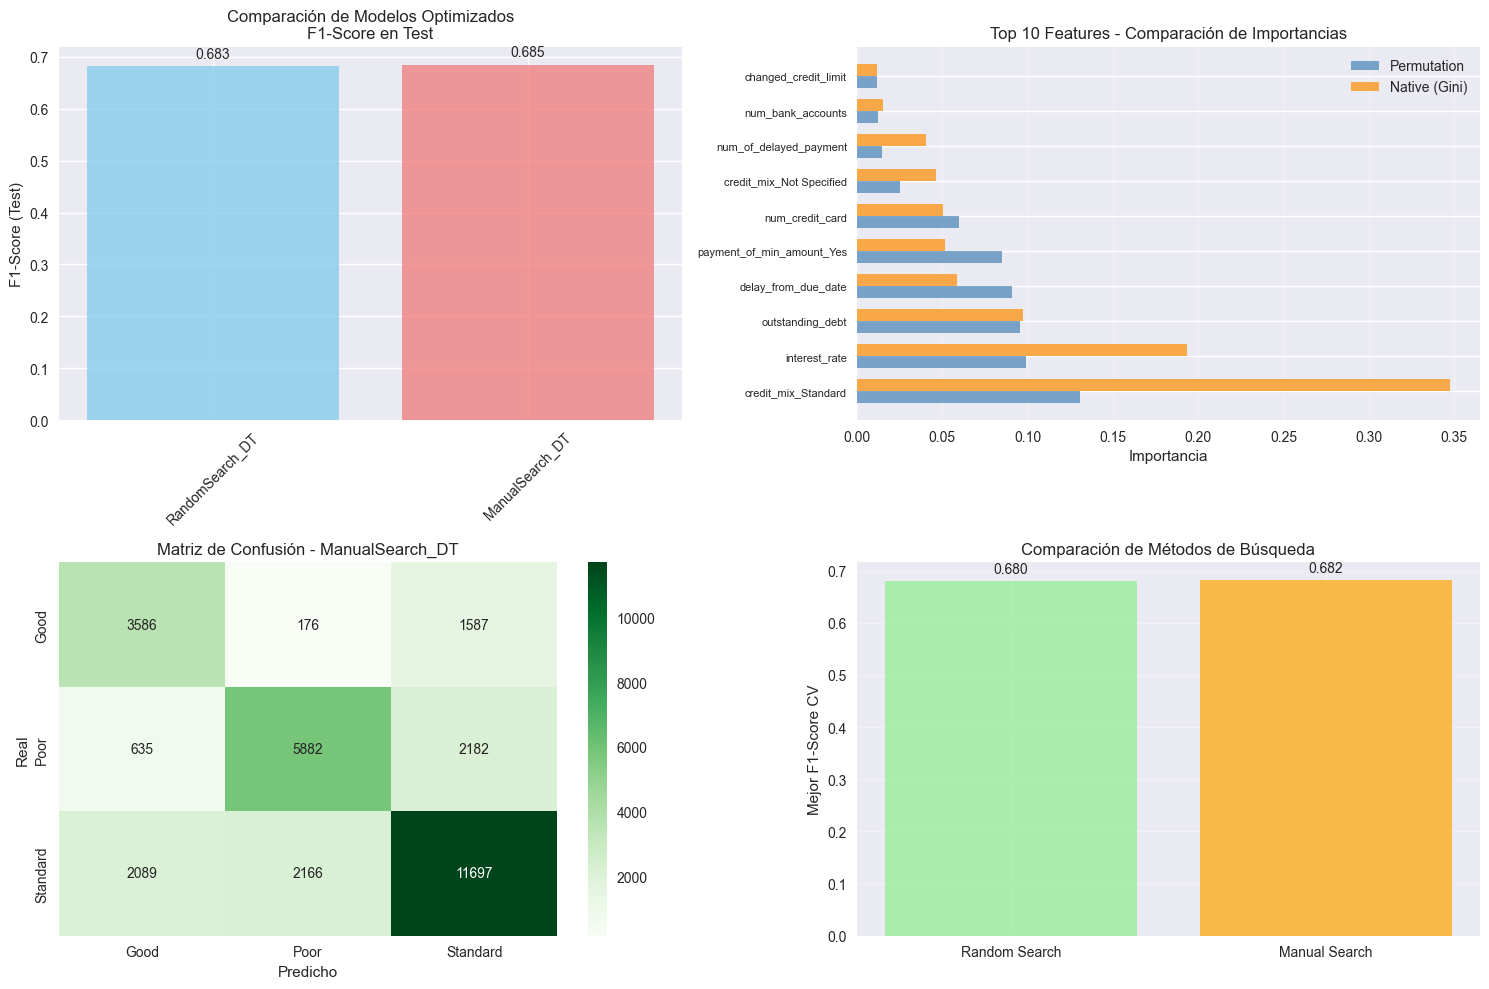


📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...
📊 Análisis de sobreajuste:
  • Diferencia promedio train-test: 0.0583
  • Configuraciones probadas: 50

🎯 RESUMEN FINAL - DECISION TREE OPTIMIZADO (VERSIÓN RÁPIDA)
⏱️  Tiempo total ejecución: 40.56s
🏆 Mejor modelo: ManualSearch_DT
📈 F1-Score Test: 0.6850 (68.50%)
🎯 Validación Cruzada: 0.6817 ± 0.0115

🔧 MEJORES HIPERPARÁMETROS:
  max_depth: 10
  min_samples_split: 2
  min_samples_leaf: 1
  criterion: gini
  class_weight: None

📊 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):
  1. credit_mix_Standard: 0.1307
  2. interest_rate: 0.0992
  3. outstanding_debt: 0.0956
  4. delay_from_due_date: 0.0911
  5. payment_of_min_amount_Yes: 0.0851

🌳 CARACTERÍSTICAS MÁS IMPORTANTES (Native):
  1. outstanding_debt: 0.3477
  2. credit_mix_Standard: 0.1937
  3. interest_rate: 0.0976
  4. payment_of_min_amount_Yes: 0.0584
  5. num_credit_card: 0.0515

⚡ EFICIENCIA COMPUTACIONAL:
  Randomized Search: 25.30s (50 iteraciones, 3-folds)
  Permutation Importance: 0.2

In [15]:
# =============================================================================
# IMPORTS NECESARIOS PARA DECISION TREE
# =============================================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

print("✅ Imports de Decision Tree cargados correctamente")

# =============================================================================
# DECISION TREE OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================

print("🧠 INICIANDO DECISION TREE OPTIMIZADO - ...")
start_time = time.time()

# Configuraciones de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# CONFIGURACIÓN RÁPIDA - OPTIMIZACIÓN CON RANDOMIZED SEARCH (PRINCIPAL)
# =============================================================================

print(f"\n🎯 INICIANDO OPTIMIZACIÓN CON RANDOMIZED SEARCH...")

# Definir pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

# Distribuciones optimizadas para Randomized Search
dt_param_distributions = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'classifier__min_samples_split': randint(2, 30),
    'classifier__min_samples_leaf': randint(1, 20),
    'classifier__max_features': [None, 'sqrt', 'log2'],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__splitter': ['best', 'random']
}

# Configurar Stratified K-Fold
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized Search CV optimizado
random_search = RandomizedSearchCV(
    dt_pipeline,
    dt_param_distributions,
    n_iter=50,  # Reducido para velocidad
    cv=skf_fast,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

print("🔍 Ejecutando Randomized Search Optimizado...")
random_start = time.time()
random_search.fit(X_train, y_train_encoded)
random_time = time.time() - random_start

print(f"✅ Randomized Search completado en {random_time:.2f}s")
print(f"🏆 Mejores parámetros: {random_search.best_params_}")
print(f"📈 Mejor score CV: {random_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_dt_config_fast(max_depth, min_samples_split, min_samples_leaf, criterion, class_weight):
    """Evalúa una configuración específica de DT (versión rápida)"""
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            class_weight=class_weight,
            random_state=42
        ))
    ])
    
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()

# Búsqueda manual optimizada - solo combinaciones prometedoras
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave...")
promising_combinations = [
    (10, 2, 1, 'gini', None),
    (15, 5, 2, 'entropy', 'balanced'),
    (20, 10, 5, 'gini', None),
    (None, 2, 1, 'gini', 'balanced'),
    (25, 5, 3, 'entropy', None),
]

for max_d, min_split, min_leaf, crit, class_w in promising_combinations:
    score = evaluate_dt_config_fast(max_d, min_split, min_leaf, crit, class_w)
    manual_results.append({
        'max_depth': max_d,
        'min_samples_split': min_split,
        'min_samples_leaf': min_leaf,
        'criterion': crit,
        'class_weight': class_w,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {
            'max_depth': max_d,
            'min_samples_split': min_split,
            'min_samples_leaf': min_leaf,
            'criterion': crit,
            'class_weight': class_w
        }

print(f"✅ Búsqueda manual rápida completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual
dt_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(**best_manual_params, random_state=42))
])
dt_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'RandomSearch_DT': random_search.best_estimator_,
    'ManualSearch_DT': dt_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada rápida
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (MUESTREO PARA VELOCIDAD)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1000 muestras)
sample_size = min(1000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['classifier'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# NATIVE FEATURE IMPORTANCE (ESPECÍFICO DE DECISION TREE)
# =============================================================================

print(f"\n🌳 CALCULANDO NATIVE FEATURE IMPORTANCE...")

best_classifier = best_model_advanced.named_steps['classifier']
native_importances = best_classifier.feature_importances_

native_df = pd.DataFrame({
    'feature': feature_names,
    'importance': native_importances
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS (Native Importance):")
print(native_df.head(10).round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 2, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Comparación Permutation vs Native Importance
plt.subplot(2, 2, 2)
top_perm = perm_df.head(10)
top_native = native_df.head(10)

x = np.arange(len(top_perm))
width = 0.35

plt.barh(x - width/2, top_perm['importance_mean'], width, 
         label='Permutation', alpha=0.7, color='steelblue')
plt.barh(x + width/2, top_native['importance'], width,
         label='Native (Gini)', alpha=0.7, color='darkorange')

plt.yticks(x, top_perm['feature'], fontsize=8)
plt.xlabel('Importancia')
plt.title('Top 10 Features - Comparación de Importancias')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')

# Gráfico 3: Matriz de confusión del mejor modelo
plt.subplot(2, 2, 3)
y_pred_best_advanced = best_results_advanced['y_pred']
cm_best_advanced = confusion_matrix(y_test_encoded, y_pred_best_advanced)
sns.heatmap(cm_best_advanced, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 4: Comparación de métodos de búsqueda
plt.subplot(2, 2, 4)
search_methods = ['Random Search', 'Manual Search']
search_scores = [random_search.best_score_, best_manual_score]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Randomized Search para análisis
results_df = pd.DataFrame(random_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - DECISION TREE OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'RandomSearch_DT':
    best_params = random_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"  {param_name}: {value}")

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n🌳 CARACTERÍSTICAS MÁS IMPORTANTES (Native):")
for i in range(5):
    feature = native_df.iloc[i]['feature']
    importance = native_df.iloc[i]['importance']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Randomized Search: {random_time:.2f}s (50 iteraciones, 3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1000 muestras)")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best_advanced, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'random_search_results': random_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'native_importance': native_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_dt_model_optimized.pkl')
print(f"\n💾 Mejor modelo guardado: 'best_dt_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - DECISION TREE OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

## NAIVE BAYES

✅ Imports de Gaussian Naive Bayes cargados correctamente
🧠 INICIANDO GAUSSIAN NAIVE BAYES OPTIMIZADO - ...

🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...
🔍 Ejecutando Grid Search Optimizado...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Grid Search completado en 11.01s
🏆 Mejores parámetros: {'classifier__var_smoothing': 1e-12}
📈 Mejor score CV: 0.6330

🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...
🔍 Explorando combinaciones clave...
✅ Búsqueda manual rápida completada
🏆 Mejores parámetros manuales: {'var_smoothing': 1e-09}
📈 Mejor score manual: 0.6330

🔍 COMPARANDO MODELOS OPTIMIZADOS...

🎯 Evaluando GridSearch_NB...
  ✅ F1-Score: 0.6324
  ✅ CV F1-Score: 0.6330 ± 0.0030

🎯 Evaluando ManualSearch_NB...
  ✅ F1-Score: 0.6324
  ✅ CV F1-Score: 0.6330 ± 0.0030

🏆 MEJOR MODELO AVANZADO: GridSearch_NB
📊 F1-Score: 0.6324

🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...
✅ Permutation Importance calculado en 0.40s

📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):
             

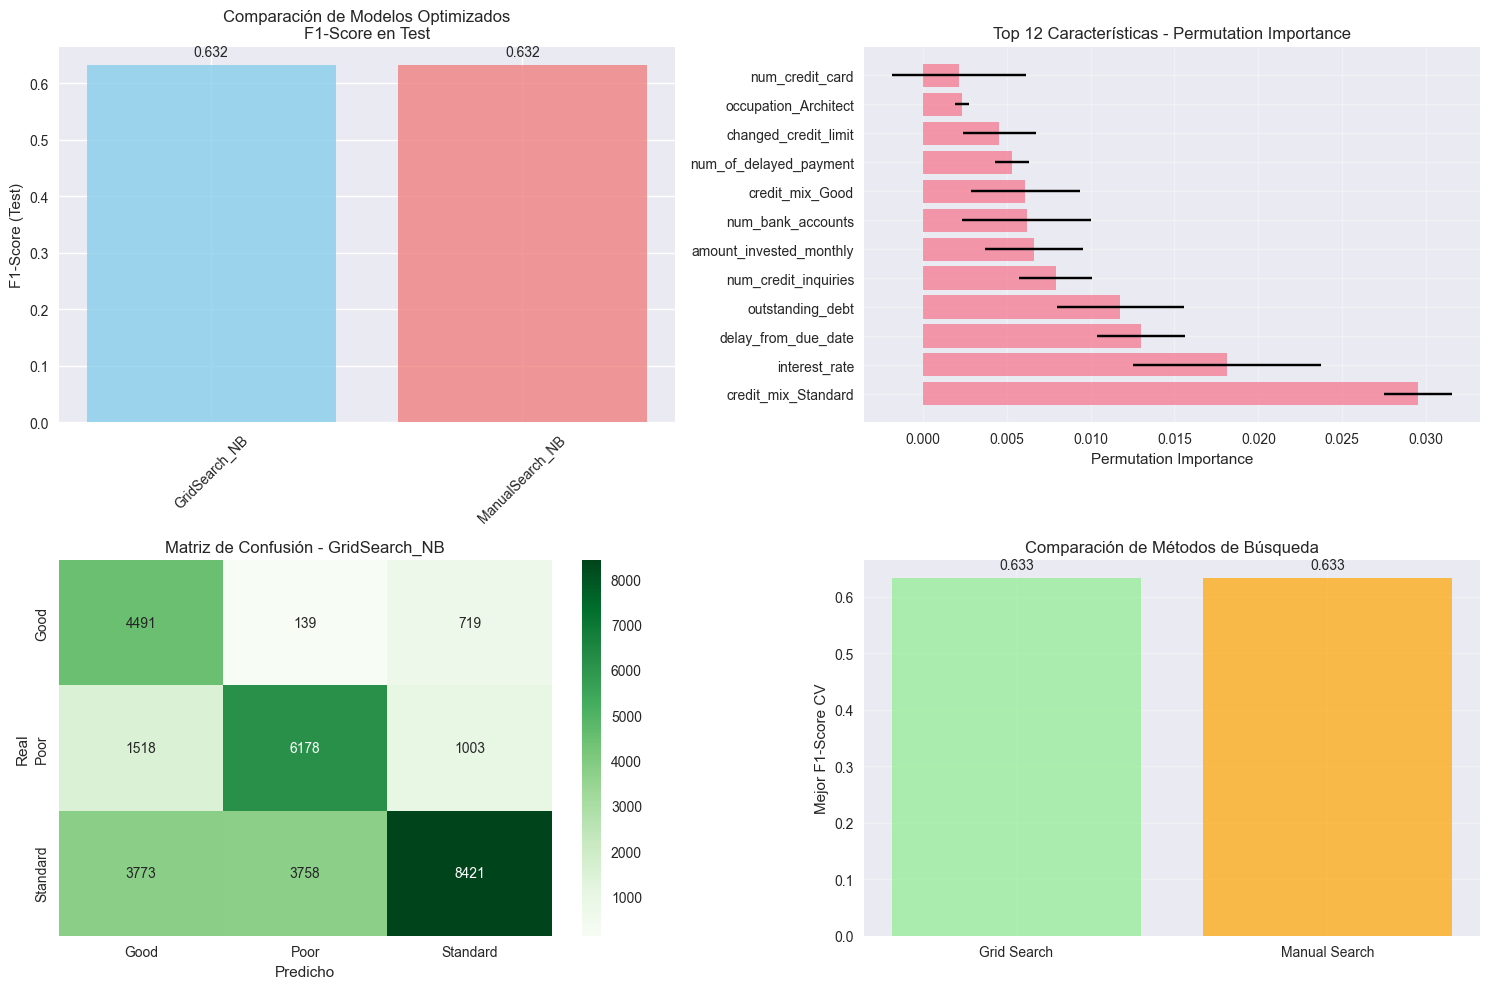


📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...
📊 Análisis de sobreajuste:
  • Diferencia promedio train-test: 0.0001
  • Configuraciones probadas: 20

🎯 RESUMEN FINAL - GAUSSIAN NAIVE BAYES OPTIMIZADO (VERSIÓN RÁPIDA)
⏱️  Tiempo total ejecución: 18.05s
🏆 Mejor modelo: GridSearch_NB
📈 F1-Score Test: 0.6324 (63.24%)
🎯 Validación Cruzada: 0.6330 ± 0.0061

🔧 MEJORES HIPERPARÁMETROS:
  var_smoothing: 1.00e-12

📊 CARACTERÍSTICAS MÁS IMPORTANTES:
  1. credit_mix_Standard: 0.0295
  2. interest_rate: 0.0181
  3. delay_from_due_date: 0.0130
  4. outstanding_debt: 0.0118
  5. num_credit_inquiries: 0.0079

⚡ EFICIENCIA COMPUTACIONAL:
  Grid Search: 11.01s (20 configuraciones, 3-folds)
  Permutation Importance: 0.40s (5 repeticiones, 1000 muestras)

📋 REPORTE CLASIFICACIÓN (GridSearch_NB):
              precision    recall  f1-score   support

        Good       0.46      0.84      0.59      5349
        Poor       0.61      0.71      0.66      8699
    Standard       0.83      0.53      0.65     15952

In [16]:
# =============================================================================
# IMPORTS NECESARIOS PARA GAUSSIAN NAIVE BAYES
# =============================================================================

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

print("✅ Imports de Gaussian Naive Bayes cargados correctamente")

# =============================================================================
# GAUSSIAN NAIVE BAYES OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================

print("🧠 INICIANDO GAUSSIAN NAIVE BAYES OPTIMIZADO - ...")
start_time = time.time()

# Configuraciones de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# CONFIGURACIÓN RÁPIDA - OPTIMIZACIÓN CON GRID SEARCH (PRINCIPAL)
# =============================================================================

print(f"\n🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...")

# Definir pipeline
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

# Grid de hiperparámetros (Naive Bayes tiene pocos parámetros)
nb_param_grid = {
    'classifier__var_smoothing': np.logspace(-12, -3, 20)  # Reducido de 30 a 20
}

# Configurar Stratified K-Fold
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid Search CV optimizado
grid_search = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=skf_fast,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("🔍 Ejecutando Grid Search Optimizado...")
grid_start = time.time()
grid_search.fit(X_train, y_train_encoded)
grid_time = time.time() - grid_start

print(f"✅ Grid Search completado en {grid_time:.2f}s")
print(f"🏆 Mejores parámetros: {grid_search.best_params_}")
print(f"📈 Mejor score CV: {grid_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_nb_config_fast(var_smoothing):
    """Evalúa una configuración específica de NB (versión rápida)"""
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB(var_smoothing=var_smoothing))
    ])
    
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()

# Búsqueda manual optimizada - solo valores clave
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave...")
promising_values = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

for var_smooth in promising_values:
    score = evaluate_nb_config_fast(var_smooth)
    manual_results.append({
        'var_smoothing': var_smooth,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {'var_smoothing': var_smooth}

print(f"✅ Búsqueda manual rápida completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual
nb_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB(**best_manual_params))
])
nb_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'GridSearch_NB': grid_search.best_estimator_,
    'ManualSearch_NB': nb_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada rápida
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (MUESTREO PARA VELOCIDAD)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1000 muestras)
sample_size = min(1000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['classifier'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 2, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance
plt.subplot(2, 2, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'], 
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Matriz de confusión del mejor modelo
plt.subplot(2, 2, 3)
y_pred_best_advanced = best_results_advanced['y_pred']
cm_best_advanced = confusion_matrix(y_test_encoded, y_pred_best_advanced)
sns.heatmap(cm_best_advanced, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 4: Comparación de métodos de búsqueda
plt.subplot(2, 2, 4)
search_methods = ['Grid Search', 'Manual Search']
search_scores = [grid_search.best_score_, best_manual_score]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Grid Search para análisis
results_df = pd.DataFrame(grid_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - GAUSSIAN NAIVE BAYES OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'GridSearch_NB':
    best_params = grid_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"  {param_name}: {value:.2e}")  # Notación científica para var_smoothing

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Grid Search: {grid_time:.2f}s (20 configuraciones, 3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1000 muestras)")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best_advanced, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'grid_search_results': grid_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_nb_model_optimized.pkl')
print(f"\n💾 Mejor modelo guardado: 'best_nb_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - GAUSSIAN NAIVE BAYES OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

## LINEAR SVC

✅ Imports de Linear SVC cargados correctamente
🧠 INICIANDO LINEAR SVC OPTIMIZADO - ...

🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...
🔍 Ejecutando Grid Search Optimizado...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
✅ Grid Search completado en 213.00s
🏆 Mejores parámetros: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__dual': False, 'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l1'}
📈 Mejor score CV: 0.6378

🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...
🔍 Explorando combinaciones clave...
✅ Búsqueda manual rápida completada
🏆 Mejores parámetros manuales: {'C': 10.0, 'penalty': 'l2', 'loss': 'squared_hinge', 'class_weight': 'balanced'}
📈 Mejor score manual: 0.6378

🔍 COMPARANDO MODELOS OPTIMIZADOS...

🎯 Evaluando GridSearch_SVC...
  ✅ F1-Score: 0.6371
  ✅ CV F1-Score: 0.6378 ± 0.0035

🎯 Evaluando ManualSearch_SVC...
  ✅ F1-Score: 0.6371
  ✅ CV F1-Score: 0.6378 ± 0.0035

🏆 MEJOR MODELO AVANZADO: GridSearch_SVC
📊 F1-Score: 0.6371

🔍 CALCU

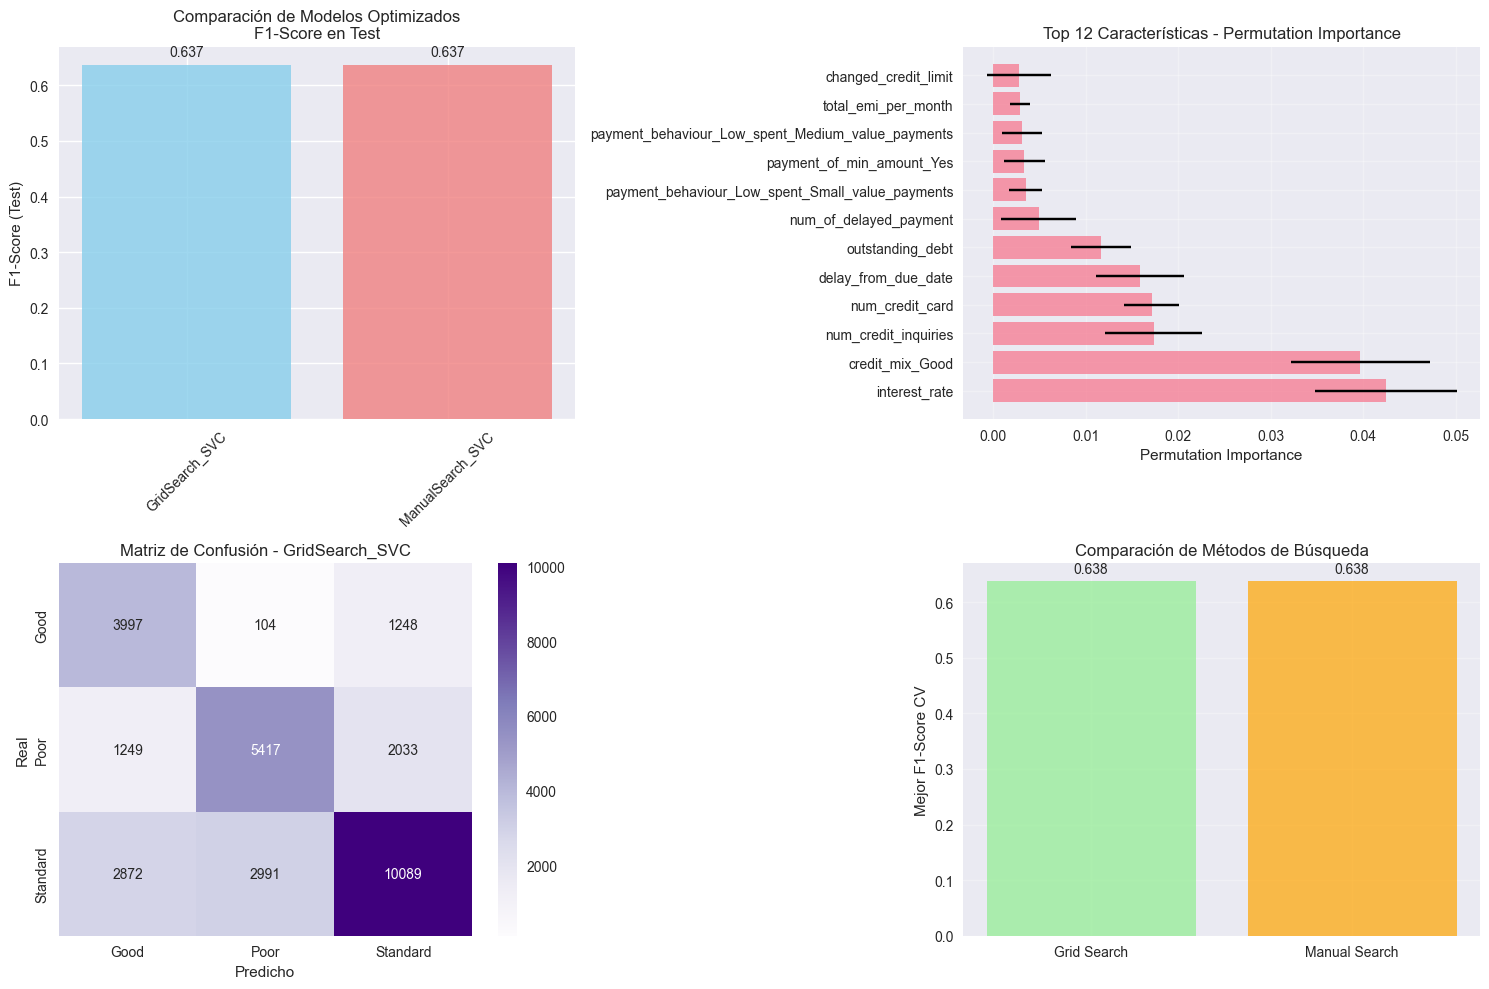


📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...
📊 Análisis de sobreajuste:
  • Diferencia promedio train-test: 0.0008
  • Configuraciones probadas: 24

🎯 RESUMEN FINAL - LINEAR SVC OPTIMIZADO (VERSIÓN RÁPIDA)
⏱️  Tiempo total ejecución: 307.42s
🏆 Mejor modelo: GridSearch_SVC
📈 F1-Score Test: 0.6371 (63.71%)
🎯 Validación Cruzada: 0.6378 ± 0.0071

🔧 MEJORES HIPERPARÁMETROS:
  C: 10
  class_weight: balanced
  dual: False
  loss: squared_hinge
  penalty: l1

📊 CARACTERÍSTICAS MÁS IMPORTANTES:
  1. interest_rate: 0.0424
  2. credit_mix_Good: 0.0397
  3. num_credit_inquiries: 0.0173
  4. num_credit_card: 0.0171
  5. delay_from_due_date: 0.0159

⚡ EFICIENCIA COMPUTACIONAL:
  Grid Search: 213.00s (24 configuraciones, 3-folds)
  Permutation Importance: 0.40s (5 repeticiones, 1000 muestras)

📋 REPORTE CLASIFICACIÓN (GridSearch_SVC):
              precision    recall  f1-score   support

        Good       0.49      0.75      0.59      5349
        Poor       0.64      0.62      0.63      8699
    Sta

In [17]:
# =============================================================================
# IMPORTS NECESARIOS PARA LINEAR SVC
# =============================================================================

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

print("✅ Imports de Linear SVC cargados correctamente")

# =============================================================================
# LINEAR SVC OPTIMIZADO: VALIDACIÓN, TUNING E INTERPRETABILIDAD
# =============================================================================

print("🧠 INICIANDO LINEAR SVC OPTIMIZADO - ...")
start_time = time.time()

# Configuraciones de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# CONFIGURACIÓN RÁPIDA - OPTIMIZACIÓN CON GRID SEARCH (PRINCIPAL)
# =============================================================================

print(f"\n🎯 INICIANDO OPTIMIZACIÓN CON GRID SEARCH...")

# Definir pipeline
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        random_state=42,
        max_iter=2000,
        dual='auto'
    ))
])

# Grid optimizado - separado por penalty para evitar combinaciones inválidas
svc_param_grid = [
    # L2 penalty con ambos loss
    {
        'classifier__penalty': ['l2'],
        'classifier__loss': ['hinge', 'squared_hinge'],
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced']
    },
    # L1 penalty solo con squared_hinge
    {
        'classifier__penalty': ['l1'],
        'classifier__loss': ['squared_hinge'],
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__dual': [False]  # L1 requiere dual=False
    }
]

# Configurar Stratified K-Fold
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid Search CV optimizado
grid_search = GridSearchCV(
    svc_pipeline,
    svc_param_grid,
    cv=skf_fast,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("🔍 Ejecutando Grid Search Optimizado...")
grid_start = time.time()
grid_search.fit(X_train, y_train_encoded)
grid_time = time.time() - grid_start

print(f"✅ Grid Search completado en {grid_time:.2f}s")
print(f"🏆 Mejores parámetros: {grid_search.best_params_}")
print(f"📈 Mejor score CV: {grid_search.best_score_:.4f}")

# =============================================================================
# BÚSQUEDA MANUAL RÁPIDA (ALTERNATIVA)
# =============================================================================

print(f"\n🎯 INICIANDO BÚSQUEDA MANUAL RÁPIDA...")

def evaluate_svc_config_fast(C, penalty, loss, class_weight):
    """Evalúa una configuración específica de SVC (versión rápida)"""
    params = {
        'C': C,
        'penalty': penalty,
        'loss': loss,
        'class_weight': class_weight,
        'random_state': 42,
        'max_iter': 2000,
        'dual': 'auto'
    }
    
    # L1 requiere dual=False
    if penalty == 'l1':
        params['dual'] = False
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LinearSVC(**params))
    ])
    
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    return cv_scores.mean()

# Búsqueda manual optimizada - solo combinaciones prometedoras
best_manual_score = 0
best_manual_params = {}
manual_results = []

print("🔍 Explorando combinaciones clave...")
promising_combinations = [
    (1.0, 'l2', 'hinge', None),
    (10.0, 'l2', 'squared_hinge', 'balanced'),
    (1.0, 'l1', 'squared_hinge', None),
    (10.0, 'l2', 'hinge', 'balanced'),
    (100.0, 'l2', 'squared_hinge', None),
]

for C, penalty, loss, class_weight in promising_combinations:
    score = evaluate_svc_config_fast(C, penalty, loss, class_weight)
    manual_results.append({
        'C': C,
        'penalty': penalty,
        'loss': loss,
        'class_weight': class_weight,
        'score': score
    })
    if score > best_manual_score:
        best_manual_score = score
        best_manual_params = {
            'C': C,
            'penalty': penalty,
            'loss': loss,
            'class_weight': class_weight
        }

print(f"✅ Búsqueda manual rápida completada")
print(f"🏆 Mejores parámetros manuales: {best_manual_params}")
print(f"📈 Mejor score manual: {best_manual_score:.4f}")

# Entrenar modelo manual
svc_manual_params = best_manual_params.copy()
svc_manual_params.update({
    'random_state': 42,
    'max_iter': 2000,
    'dual': False if best_manual_params['penalty'] == 'l1' else 'auto'
})
svc_manual = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(**svc_manual_params))
])
svc_manual.fit(X_train, y_train_encoded)

# =============================================================================
# COMPARACIÓN RÁPIDA DE MODELOS OPTIMIZADOS
# =============================================================================

print(f"\n🔍 COMPARANDO MODELOS OPTIMIZADOS...")

models = {
    'GridSearch_SVC': grid_search.best_estimator_,
    'ManualSearch_SVC': svc_manual
}

results_advanced = {}

for model_name, model in models.items():
    print(f"\n🎯 Evaluando {model_name}...")
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro')
    recall = recall_score(y_test_encoded, y_pred, average='macro')
    f1 = f1_score(y_test_encoded, y_pred, average='macro')
    
    # Validación cruzada rápida
    cv_scores = cross_val_score(
        model, X_train, y_train_encoded, 
        cv=skf_fast, scoring='f1_macro', n_jobs=-1
    )
    
    results_advanced[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ✅ CV F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Seleccionar mejor modelo
best_model_name = max(results_advanced.items(), key=lambda x: x[1]['f1'])[0]
best_model_advanced = results_advanced[best_model_name]['model']
best_results_advanced = results_advanced[best_model_name]

print(f"\n🏆 MEJOR MODELO AVANZADO: {best_model_name}")
print(f"📊 F1-Score: {best_results_advanced['f1']:.4f}")

# =============================================================================
# INTERPRETABILIDAD - PERMUTATION IMPORTANCE (MUESTREO PARA VELOCIDAD)
# =============================================================================

print(f"\n🔍 CALCULANDO PERMUTATION IMPORTANCE (MUESTREADO)...")

# Preparar datos preprocesados
X_test_processed = preprocessor.transform(X_test)

# Muestrear para mayor velocidad (usar solo 1000 muestras)
sample_size = min(1000, X_test_processed.shape[0])
sample_indices = np.random.choice(X_test_processed.shape[0], sample_size, replace=False)
X_test_sampled = X_test_processed[sample_indices]
y_test_sampled = y_test_encoded[sample_indices]

# Calcular permutation importance con muestreo
perm_start = time.time()
perm_importance = permutation_importance(
    best_model_advanced.named_steps['classifier'],
    X_test_sampled,
    y_test_sampled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)
perm_time = time.time() - perm_start

print(f"✅ Permutation Importance calculado en {perm_time:.2f}s")

# Crear DataFrame con resultados
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Permutation):")
print(perm_df.head(10).round(4))

# =============================================================================
# VISUALIZACIONES ESENCIALES
# =============================================================================

plt.figure(figsize=(15, 10))

# Gráfico 1: Comparación de modelos optimizados
plt.subplot(2, 2, 1)
model_names = list(results_advanced.keys())
f1_scores = [results_advanced[model]['f1'] for model in model_names]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(model_names, f1_scores, color=colors, alpha=0.8)
plt.ylabel('F1-Score (Test)')
plt.title('Comparación de Modelos Optimizados\nF1-Score en Test')
plt.xticks(rotation=45)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico 2: Permutation Importance
plt.subplot(2, 2, 2)
top_perm = perm_df.head(12)
plt.barh(range(len(top_perm)), top_perm['importance_mean'], 
         xerr=top_perm['importance_std'], alpha=0.7, capsize=5)
plt.yticks(range(len(top_perm)), top_perm['feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 12 Características - Permutation Importance')
plt.grid(True, alpha=0.3)

# Gráfico 3: Matriz de confusión del mejor modelo
plt.subplot(2, 2, 3)
y_pred_best_advanced = best_results_advanced['y_pred']
cm_best_advanced = confusion_matrix(y_test_encoded, y_pred_best_advanced)
sns.heatmap(cm_best_advanced, annot=True, fmt='d', cmap='Purples', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')

# Gráfico 4: Comparación de métodos de búsqueda
plt.subplot(2, 2, 4)
search_methods = ['Grid Search', 'Manual Search']
search_scores = [grid_search.best_score_, best_manual_score]

bars = plt.bar(search_methods, search_scores, alpha=0.7, 
               color=['lightgreen', 'orange'])
plt.ylabel('Mejor F1-Score CV')
plt.title('Comparación de Métodos de Búsqueda')
for bar, score in zip(bars, search_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS RÁPIDO DE COMPORTAMIENTO
# =============================================================================

print(f"\n📈 ANALIZANDO COMPORTAMIENTO DEL MODELO...")

# Usar resultados de Grid Search para análisis
results_df = pd.DataFrame(grid_search.cv_results_)
train_scores = results_df['mean_train_score']
test_scores = results_df['mean_test_score']
gap = train_scores - test_scores

print(f"📊 Análisis de sobreajuste:")
print(f"  • Diferencia promedio train-test: {gap.mean():.4f}")
print(f"  • Configuraciones probadas: {len(results_df)}")

# =============================================================================
# RESUMEN FINAL OPTIMIZADO
# =============================================================================

end_time = time.time()
execution_time = end_time - start_time

print("\n" + "="*80)
print("🎯 RESUMEN FINAL - LINEAR SVC OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)

print(f"⏱️  Tiempo total ejecución: {execution_time:.2f}s")
print(f"🏆 Mejor modelo: {best_model_name}")
print(f"📈 F1-Score Test: {best_results_advanced['f1']:.4f} ({best_results_advanced['f1']*100:.2f}%)")
print(f"🎯 Validación Cruzada: {best_results_advanced['cv_mean']:.4f} ± {best_results_advanced['cv_std']*2:.4f}")

print(f"\n🔧 MEJORES HIPERPARÁMETROS:")
if best_model_name == 'GridSearch_SVC':
    best_params = grid_search.best_params_
else:
    best_params = best_manual_params

for param, value in best_params.items():
    param_name = param.replace('classifier__', '')
    print(f"  {param_name}: {value}")

print(f"\n📊 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i in range(5):
    feature = perm_df.iloc[i]['feature']
    importance = perm_df.iloc[i]['importance_mean']
    print(f"  {i+1}. {feature}: {importance:.4f}")

print(f"\n⚡ EFICIENCIA COMPUTACIONAL:")
print(f"  Grid Search: {grid_time:.2f}s ({len(results_df)} configuraciones, 3-folds)")
print(f"  Permutation Importance: {perm_time:.2f}s (5 repeticiones, 1000 muestras)")

print(f"\n📋 REPORTE CLASIFICACIÓN ({best_model_name}):")
print(classification_report(y_test_encoded, y_pred_best_advanced, target_names=le.classes_))

# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

advanced_results = {
    'best_model': best_model_advanced,
    'best_model_name': best_model_name,
    'best_params': best_params,
    'grid_search_results': grid_search.cv_results_,
    'manual_search_results': manual_results,
    'permutation_importance': perm_df,
    'feature_names': feature_names,
    'results_advanced': results_advanced,
    'execution_time': execution_time,
    'preprocessor': preprocessor,
    'label_encoder': le
}

# Guardar el mejor modelo por separado
joblib.dump(best_model_advanced, 'best_svc_model_optimized.pkl')
print(f"\n💾 Mejor modelo guardado: 'best_svc_model_optimized.pkl'")

print("="*80)
print("✅ ANÁLISIS COMPLETADO - LINEAR SVC OPTIMIZADO (VERSIÓN RÁPIDA)")
print("="*80)